# Определение цвета объектов на изображении

Проект выполнен в тетрадке 03_detect_color.ipynb 

## Описание проекта

Проект направлен на автоматическое определение цвета объектов (капсул, таблеток, софтгелей) на изображениях.

Цель — построить полный ML‑пайплайн, который:
- получает исходные фотографии с несколькими объектами;
- детектирует каждый объект с помощью YOLO (предварительно обученной модели);
- вырезает кропы объектов;
- выполняет предобработку (smart crop, glare removal);
- извлекает цветовые признаки в различных цветовых пространствах;
- классифицирует цвет объекта с помощью ML‑модели (RF / KNN / XGBoost / LightGBM).

Проект решает задачу стандартизации цвета объектов для контроля качества и последующей аналитики.

Необходимо получить стабильные цветовые признаки, не зависящие от:
- освещения,
- бликов,
- надписей на капсулах,
- зелёного фона пакетика,
- соседних объектов.

## Описание данных

Исходные данные:
  - Папка 01_ydb_photo — изображения с несколькими объектами.
  - Папка 01_ydb_labels — YOLO‑разметка объектов (capsule, softgel_gelcap, meltlet, caplet).

Фильтрация данных
- Для определения цвета используются только изображения класса no_def, т.е. объекты без дефектов:
  - Папка 02_ydp_photo/no_def 
  - По этим именам выбираются соответствующие изображения и разметки из 01_ydb_photo и 01_ydb_labels.

Детекция объектов:
- Используется обученная модель YOLO:
  - модель: 01_ydb_runs/train/weights/best.pt
  - детекция выполняется по всем изображениям из 03_ydb_photo
  - сохраняются:
    - JSON‑файлы с метаданными
    - кропы объектов (если изображение детектировано без ошибок)

Структура данных после детекции:

```python
03_ydb_infer/
   IMG_01/
      crops_IMG_01/
         IMG_01_crop_0_softgel_gelcap.jpg
         IMG_01_crop_1_capsule.jpg
         ...
      IMG_01.json
   IMG_02/
      ...
```


Подготовка датасета для классификации цвета:
- Кропы сортируются по классам:
```python
03_cd_st1/
   capsule/
   softgel_gelcap/
   meltlet/
   caplet/
```

📌 После Шага 2 (Smart Crop)
- Удалены края пакетика, зелёный фон, надписи.
- Созданы debug‑картинки:
  - оригинал → shrink → маска надписей → итоговый кроп.
  
📌 После Шага 3 (Glare Removal)
- Удалены блики через мягкую маску HSV+LAB.
- Сохранены:
  - очищенные кропы,
  - маски бликов,
  - debug‑визуализации.
  
📌 После Шага 4 (HSV/LAB)
- Для каждого кропа сохранено:
  - *_hsv.npy — полное HSV‑изображение
  - *_lab.npy — полное LAB‑изображение
  - *_hsv_valid.npy — валидные пиксели без бликов
  - *_lab_valid.npy — валидные пиксели без бликов  

📌 После Шага 5 (Color Features)
- Создана таблица:
  - Содержит 22 цветовых признака:
    - статистики Hue (медиана, p10, p90, энтропия),
    - средние S, V, L,
    - LAB‑медианы,
    - KMeans‑центры (k=1, k=2),
    - расстояние до белого,  
    - разброс LAB.

## Выбор метрик

Метрики качества детекции YOLO: 
- Используются для проверки корректности кропов:
  - IoU (Intersection over Union)
    - применяется для сопоставления предсказанного bbox с GT
    - порог: 0.5
    - используется для расчёта TP/FP/FN
  - Precision
    - показывает, насколько мало ложных срабатываний.
  - Recall
    - показывает, насколько полно YOLO находит объекты.
  - F1-score
    - Сводная метрика качества детекции.

Метрики качества подготовки данных:
- Mismatch count
  - количество изображений, где YOLO нашёл другое число объектов, чем в разметке.
- Bad IoU images
  - изображения, где хотя бы один объект имеет IoU < 0.5.
- Perfect images
  - изображения, где:
    - количество объектов совпало,
    - IoU ≥ 0.5 для всех объектов.
- Только такие изображения используются для дальнейших шагов.

Метрики качества признаков
- ✔ Разделимость классов в LAB‑пространстве
  - scatter‑графики A vs B
  - heatmap плотности
  - группировка по округлённым A/B
  - Позволяет оценить, насколько классы имеют разные цветовые кластеры.
- ✔ Разделимость по Hue
  - гистограммы H_median
  - энтропия Hue
  - Показывает, насколько оттенок стабилен внутри класса.
- ✔ Стабильность признаков
  - стандартное отклонение A_std, B_std
  - H_norm_std
  - LAB_dist_white
  - Если признаки стабильны → модель ML будет работать надёжно.

Для задачи классификации цвета (Шаг 6) будут использоваться:
- 1. Accuracy
  - Основная метрика — доля правильно определённых цветов.
- 2. F1-score (per class)
  - Важно из‑за дисбаланса классов (например, meltlet всего 1.9%).
- 3. Confusion Matrix
  - Покажет, какие цвета путаются между собой.
- 4. ROC‑AUC (опционально)
  - Если модель будет выдавать вероятности.
- 5. Entropy / Variance пикселей
  - Используется на Шаге 5 для оценки качества цветовых признаков.

<a class="anchor" id="contents"></a>
# Содержание:<a class="anchor" id="ch03"></a>

* [Шаг 0: Подготовка данных](#ch03_0)
* [Шаг 1: Подготовка кропов объектов](#ch03_1)
* [Шаг 2. Умная обрезка (Smart Crop / Preprocessing)](#ch03_2)
* [Шаг 3. Удаление бликов (Glare Removal)](#ch03_3)
* [Шаг 4. Преобразование в цветовое пространство](#ch03_4)
* [Шаг 5. Извлечение цветовых признаков (Color Features)](#ch03_5)
* [Шаг 6. Классификация цвета (ML модель)](#ch03_6)

# Технический стэк

In [73]:
import os
import cv2
import time
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
import shutil
from glob import glob


from ultralytics import YOLO
import yaml

from sklearn.cluster import KMeans
from scipy.stats import entropy

from scipy.stats import entropy, randint, uniform
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_recall_curve, f1_score    
)

import joblib

In [2]:
%matplotlib inline

In [3]:
start_all = time.time()

# Шаг 0: Подготовка данных <a class="anchor" id="ch03_0"></a>

In [4]:
SRC_IMG = r"01_ydb_photo"
SRC_LBL = r"01_ydb_labels"

FILTER_DIR = r"02_ydp_photo\no_def"

OUT_IMG = r"03_ydb_photo"
OUT_LBL = r"03_ydb_labels"

os.makedirs(OUT_IMG, exist_ok=True)
os.makedirs(OUT_LBL, exist_ok=True)

# 1. Собираем имена файлов из no_def
filter_names = {
    os.path.splitext(f)[0]
    for f in os.listdir(FILTER_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
}

print("Файлов для отбора:", len(filter_names))

# 2. Копируем совпадающие изображения и разметку
for name in filter_names:
    img_src = os.path.join(SRC_IMG, name + ".jpg")
    if not os.path.exists(img_src):
        img_src = os.path.join(SRC_IMG, name + ".png")
    if not os.path.exists(img_src):
        print("Нет изображения:", name)
        continue

    lbl_src = os.path.join(SRC_LBL, name + ".txt")

    # копируем изображение
    shutil.copy(img_src, os.path.join(OUT_IMG, os.path.basename(img_src)))

    # копируем разметку, если есть
    if os.path.exists(lbl_src):
        shutil.copy(lbl_src, os.path.join(OUT_LBL, name + ".txt"))
    else:
        print("Нет разметки:", name)

print("\nГотово: изображения и разметка сохранены.")

Файлов для отбора: 1399

Готово: изображения и разметка сохранены.


In [ ]:
start = time.time()

# -----------------------------
# 1. Пути к данным и конфигурации
# -----------------------------
INPUT_DIR = "03_ydb_photo"
LABELS_DIR = "03_ydb_labels"
OUTPUT_DIR = "03_ydb_infer"
DATASET_YAML = "01_ydb_dataset.yaml"

# --- ДО создания папок добавляем ---
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
# -----------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# 2. Читаем классы из dataset.yaml
# -----------------------------
with open(DATASET_YAML, "r", encoding="utf-8") as f:
    yml = yaml.safe_load(f)

class_names = yml["names"]

# -----------------------------
# 3. Загружаем обученную YOLO модель
# -----------------------------
model = YOLO(r"01_ydb_runs\train\weights\best.pt")

# -----------------------------
# 4. Инициализация статистики
# -----------------------------
total_images = 0
total_expected = 0
total_found = 0

class_stats = {cls: {"name": name, "count": 0} for cls, name in class_names.items()}

pre_times = []
inf_times = []
post_times = []

mismatch_images = []
bad_quality_images = []
error_images = set()   # <<< важно

global_TP = 0
global_FP = 0
global_FN = 0

perfect_objects = 0 
# -----------------------------
# IoU функция
# -----------------------------
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)

# -----------------------------
# 5. Основной цикл
# -----------------------------
for filename in os.listdir(INPUT_DIR):
    if not filename.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(INPUT_DIR, filename)
    img = cv2.imread(img_path)

    if img is None:
        print(f"⚠️ Не удалось прочитать изображение: {filename}")
        continue

    H, W = img.shape[:2]
    total_images += 1

    base = os.path.splitext(filename)[0]
    label_path = os.path.join(LABELS_DIR, base + ".txt")

    # -----------------------------
    # Читаем GT
    # -----------------------------
    gt_boxes = []
    gt_classes = []
    expected = 0

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.read().splitlines()

        expected = len(lines)
        for line in lines:
            cls, xc, yc, w, h = map(float, line.split())
            x1 = int((xc - w/2) * W)
            y1 = int((yc - h/2) * H)
            x2 = int((xc + w/2) * W)
            y2 = int((yc + h/2) * H)
            gt_boxes.append([x1, y1, x2, y2])
            gt_classes.append(int(cls))

    total_expected += expected

    # -----------------------------
    # YOLO детекция
    # -----------------------------
    results = model(
        img_path,
        conf=0.40,     ###############################################################
        iou=0.40,      ###############################################################
        device=0,
        verbose=False,
        imgsz=640
    )[0]

    pre_times.append(results.speed['preprocess'])
    inf_times.append(results.speed['inference'])
    post_times.append(results.speed['postprocess'])

    # -----------------------------
    # Предсказанные боксы + классы
    # -----------------------------
    pred_boxes = []
    pred_classes = []

    for b in results.boxes:
        x1, y1, x2, y2 = map(int, b.xyxy[0])
        pred_boxes.append([x1, y1, x2, y2])
        pred_classes.append(int(b.cls[0]))

    found = len(pred_boxes)
    total_found += found

    # -----------------------------
    # TP/FP/FN
    # -----------------------------
    TP = 0
    matched_gt = set()

    for pb, pcl in zip(pred_boxes, pred_classes):
        best_iou = 0
        best_gt = -1

        for idx, (gb, gcl) in enumerate(zip(gt_boxes, gt_classes)):
            current_iou = iou(pb, gb)
            if current_iou > best_iou:
                best_iou = current_iou
                best_gt = idx

        if best_iou >= 0.5 and best_gt not in matched_gt and pcl == gt_classes[best_gt]:
            TP += 1
            matched_gt.add(best_gt)

    FP = len(pred_boxes) - TP
    FN = len(gt_boxes) - TP

    global_TP += TP
    global_FP += FP
    global_FN += FN

    # -----------------------------
    # ОПРЕДЕЛЯЕМ ОШИБКИ ДЛЯ ТЕКУЩЕГО ИЗОБРАЖЕНИЯ
    # -----------------------------
    has_error = False

    if expected != found:
        mismatch_images.append((filename, expected, found))
        has_error = True

    if FP > 0 or FN > 0:
        bad_quality_images.append((filename, TP, FP, FN))
        has_error = True

    if has_error:
        error_images.add(filename)
    else:
        perfect_objects += found
        
    # -----------------------------
    # Сохранение результатов
    # -----------------------------
    out_dir = os.path.join(OUTPUT_DIR, base)
    
    # создаём папку ТОЛЬКО если изображение идеальное
    if filename not in error_images:
        crops_dir = os.path.join(out_dir, f"crops_{base}")
        os.makedirs(crops_dir, exist_ok=True)
    else:
        crops_dir = None

    json_data = {
        "image": filename,
        "width": W,
        "height": H,
        "expected_objects": expected,
        "found_objects": found,
        "objects": []
    }

    for i, (box, cls) in enumerate(zip(pred_boxes, pred_classes)):
        x1, y1, x2, y2 = box
        conf = float(results.boxes[i].conf[0])

        crop = img[y1:y2, x1:x2]
        class_name = class_names.get(cls, "unknown")
        crop_name = f"{base}_crop_{i}_{class_name}.jpg"
        
        # сохраняем кропы ТОЛЬКО если изображение БЕЗ ошибок
        if crops_dir is not None:
            cv2.imwrite(os.path.join(crops_dir, crop_name), crop, [cv2.IMWRITE_JPEG_QUALITY, 85])


        w = x2 - x1
        h = y2 - y1
        xc = x1 + w / 2
        yc = y1 + h / 2

        json_data["objects"].append({
            "crop_id": i,
            "crop_file": crop_name,
            "class": cls,
            "class_name": class_name,
            "confidence": conf,
            "bbox": {
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "width": w,
                "height": h
            },
            "bbox_yolo": [
                xc / W,
                yc / H,
                w / W,
                h / H
            ]
        })

        class_stats[cls]["count"] += 1

    # сохраняем JSON только если изображение идеальное
    if filename not in error_images:
        json_path = os.path.join(out_dir, f"{base}.json")
        os.makedirs(out_dir, exist_ok=True)
        with open(json_path, "w") as f:
            json.dump(json_data, f)


# -----------------------------
# 6. Итоговая статистика
# -----------------------------
print("\n" + "="*60)
print("Готово. Итоговая статистика:")
print("="*60)

print(f"Обработано изображений: {total_images}")
print(f"Всего объектов в разметке: {total_expected}")
print(f"Всего найдено YOLO (TP+FP): {total_found}")

perfect_images_count = total_images - len(error_images)

print("\n=== Идеальные изображения (без ошибок) ===")
print(f"Всего: {perfect_images_count}")
print(f"Всего объектов в идеальных изображениях: {perfect_objects}") 
print(f"Идеальные изображения сохранены в папку: {OUTPUT_DIR}")

# -----------------------------
# Статистика по классам
# -----------------------------
print("\nРаспределение по классам:")
for cls, data in class_stats.items():
    count = data["count"]
    percentage = (count / total_found * 100) if total_found > 0 else 0
    print(f"  • {data['name']} (класс {cls}): {count} ({percentage:.1f}%)")

# -----------------------------
# Mismatch
# -----------------------------
print("\n=== Несовпадения количества объектов ===")
if mismatch_images:
    print(f"Всего: {len(mismatch_images)} изображений")
    for name, exp, fnd in mismatch_images:
        print(f"  • {name}: expected={exp}, found={fnd}")
else:
    print("Все изображения совпадают идеально.")

# -----------------------------
# Плохое качество IoU
# -----------------------------
print("\n=== Плохое качество детекции (IoU < 0.5) ===")
if bad_quality_images:
    print(f"Всего: {len(bad_quality_images)} изображений")
    for name, tp, fp, fn in bad_quality_images:
        print(f"  • {name}: TP={tp}, FP={fp}, FN={fn}")
else:
    print("Все изображения детектированы качественно.")

# -----------------------------
# Precision / Recall / F1
# -----------------------------
precision = global_TP / (global_TP + global_FP) if (global_TP + global_FP) > 0 else 0
recall = global_TP / (global_TP + global_FN) if (global_TP + global_FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")

# -----------------------------
# Время
# -----------------------------
print("\n=== Статистика инференса ===")
print(f"Средний preprocess: {np.mean(pre_times):.2f} ms")
print(f"Средний inference:  {np.mean(inf_times):.2f} ms")
print(f"Средний postprocess:{np.mean(post_times):.2f} ms")

end = time.time()
elapsed = end - start

print("\n" + "="*60)
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")
print(f"⏱️ Среднее на изображение: {elapsed/total_images:.2f} секунд")
print("="*60)

```python
============================================================
Готово. Итоговая статистика:
============================================================
Обработано изображений: 1399
Всего объектов в разметке: 5296
Всего найдено YOLO (TP+FP): 5292

=== Идеальные изображения (без ошибок) ===
Всего: 1386
Всего объектов в идеальных изображениях: 5249
Идеальные изображения сохранены в папку: 03_ydb_infer

Распределение по классам:
  • capsule (класс 0): 3091 (58.4%)
  • softgel_gelcap (класс 1): 1701 (32.1%)
  • meltlet (класс 2): 100 (1.9%)
  • caplet (класс 3): 400 (7.6%)

=== Несовпадения количества объектов ===
Всего: 8 изображений
  • IMG_.jpg: expected=3, found=4
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=2, found=3

=== Плохое качество детекции (IoU < 0.5) ===
Всего: 13 изображений
  • IMG_.jpg: TP=3, FP=1, FN=0
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=4, FP=1, FN=1
  • IMG_.jpg: TP=3, FP=2, FN=2
  • IMG_.jpg: TP=4, FP=1, FN=1
  • IMG_.jpg: TP=3, FP=1, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=4, FP=1, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=1, FN=0

Precision: 99.85%
Recall:    99.77%
F1-score:  99.81%

=== Статистика инференса ===
Средний preprocess: 3.61 ms
Средний inference:  50.92 ms
Средний postprocess:1.59 ms

============================================================
⏱️ Общее время: 10.30 минут (617.9 секунд)
⏱️ Среднее на изображение: 0.44 секунд
============================================================
```

<div class="alert alert-info">
  <b> * <a href="#ch03">к содержанию</a> </b> 
</div>

---

# Шаг 1: Подготовка кропов объектов <a class="anchor" id="ch03_1"></a>

- структура  по изображениям с крропами объектов:

```python
\03_ydb_infer:
    \IMG_01:
        \crops_IMG_01:
            IMG_01_crop_0_softgel_gelcap.jpg
            IMG_01_crop_1_softgel_gelcap.jpg
            IMG_01_crop_2_capsule.jpg
            IMG_01_crop_3_softgel_gelcap.jpg
        
        IMG_01.json
    \IMG_02:
        \crops_IMG_02:
            IMG_02_crop_0_softgel_gelcap.jpg
            IMG_02_crop_1_softgel_gelcap.jpg
            IMG_02_crop_2_capsule.jpg
            IMG_02_crop_3_softgel_gelcap.jpg
        
        IMG_02.json
    
    .....

```

In [6]:
# ==========================
# НАСТРОЙКИ ПУТЕЙ
# ==========================
INPUT_FOLDER = r"02_yolo_EfficientNet‑B3\03_ydb_infer"
OUTPUT_FOLDER = r"02_yolo_EfficientNet‑B3\03_cd_st1"

# Классы объектов
CLASS_NAMES = ["capsule", "softgel_gelcap", "meltlet", "caplet"]

# ==========================
# СОЗДАНИЕ ПАПОК
# ==========================
for cls in CLASS_NAMES:
    os.makedirs(os.path.join(OUTPUT_FOLDER, cls), exist_ok=True)

# Счётчики для новых имён
counters = {cls: 1 for cls in CLASS_NAMES}

# ==========================
# ОБРАБОТКА КРОПОВ
# ==========================
for img_folder in os.listdir(INPUT_FOLDER):
    full_folder = os.path.join(INPUT_FOLDER, img_folder)
    if not os.path.isdir(full_folder):
        continue

    crop_dirs = [d for d in os.listdir(full_folder) if d.startswith("crops_")]
    if not crop_dirs:
        continue

    crop_dir = os.path.join(full_folder, crop_dirs[0])
    crop_files = glob(os.path.join(crop_dir, "*.jpg"))

    for crop_path in crop_files:
        filename = os.path.basename(crop_path)

        after_crop = filename.split("_crop_")[-1]
        parts = after_crop.split("_")
        cls = "_".join(parts[1:]).replace(".jpg", "")

        if cls not in CLASS_NAMES:
            print(f"⚠ Неизвестный класс: {cls} в файле {filename}")
            continue

        new_name = f"{cls}_{counters[cls]:04d}.jpg"
        counters[cls] += 1

        dst_path = os.path.join(OUTPUT_FOLDER, cls, new_name)
        shutil.copy2(crop_path, dst_path)

print("✓ Готово! Все кропы собраны в 03_ydb_infer.")


# ==========================
# СТАТИСТИКА ДЛЯ 01_ydb_infer
# ==========================
def collect_stats_from_infer(folder):
    stats = {cls: 0 for cls in CLASS_NAMES}

    for img_folder in os.listdir(folder):
        full_folder = os.path.join(folder, img_folder)
        if not os.path.isdir(full_folder):
            continue

        crop_dirs = [d for d in os.listdir(full_folder) if d.startswith("crops_")]
        if not crop_dirs:
            continue

        crop_dir = os.path.join(full_folder, crop_dirs[0])
        crop_files = glob(os.path.join(crop_dir, "*.jpg"))

        for crop_path in crop_files:
            filename = os.path.basename(crop_path)

            after_crop = filename.split("_crop_")[-1]
            parts = after_crop.split("_")
            cls = "_".join(parts[1:]).replace(".jpg", "")

            if cls in CLASS_NAMES:
                stats[cls] += 1

    return stats


# ==========================
# СТАТИСТИКА ДЛЯ 03_ydb_infer
# ==========================
def collect_stats(folder):
    stats = {cls: 0 for cls in CLASS_NAMES}

    for cls in CLASS_NAMES:
        cls_folder = os.path.join(folder, cls)
        if os.path.exists(cls_folder):
            stats[cls] = len([
                f for f in os.listdir(cls_folder)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
    return stats


def print_stats(title, stats):
    total = sum(stats.values())
    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"Всего объектов: {total}\n")
    print("Распределение по классам:")

    for i, cls in enumerate(CLASS_NAMES):
        count = stats[cls]
        pct = (count / total * 100) if total > 0 else 0
        print(f"  • {cls} (класс {i}): {count} ({pct:.1f}%)")
    print()


# ==========================
# ВЫВОД СТАТИСТИКИ
# ==========================
stats_old = collect_stats_from_infer(INPUT_FOLDER)
stats_new = collect_stats(OUTPUT_FOLDER)

print_stats("СТАТИСТИКА 01_ydb_infer", stats_old)
print_stats("СТАТИСТИКА 03_ydb_infer", stats_new)

✓ Готово! Все кропы собраны в 03_ydb_infer.
СТАТИСТИКА 01_ydb_infer
Всего объектов: 5249

Распределение по классам:
  • capsule (класс 0): 3061 (58.3%)
  • softgel_gelcap (класс 1): 1694 (32.3%)
  • meltlet (класс 2): 100 (1.9%)
  • caplet (класс 3): 394 (7.5%)

СТАТИСТИКА 03_ydb_infer
Всего объектов: 5249

Распределение по классам:
  • capsule (класс 0): 3061 (58.3%)
  • softgel_gelcap (класс 1): 1694 (32.3%)
  • meltlet (класс 2): 100 (1.9%)
  • caplet (класс 3): 394 (7.5%)



- структура  по изображениям с крропами объектов для детекции цвета:

```python
\03_cd_st1:
    \caplet:
            caplet_0001.jpg
            caplet_0002.jpg
            .....
    \capsule:
            capsule_0001.jpg
            capsule_0002.jpg
             .....
    \meltlet:           
            meltlet_0001.jpg
            meltlet_0002.jpg
             .....
    \softgel_gelcap:           
            softgel_gelcap_0001.jpg
            softgel_gelcap_0002.jpg
             .....
```

<div style="border:solid green 4px; padding: 5px">

__Выводы по Шагу 0 - 1:__

✔️ Данные успешно подготовлены: отфильтрованы изображения класса no_def, скопированы соответствующие разметки.

✔️ YOLO‑детекция работает стабильно:
- Precision ≈ 99.85%
- Recall ≈ 99.77%
- F1 ≈ 99.81%
Это означает, что кропы объектов получены практически идеально.

✔️ Количество ошибок минимально:
- 8 изображений с mismatch
- 13 изображений с плохим IoU
Это меньще 1.5% от всего датасета.

✔️ Классовый баланс сохранён — распределение объектов в кропах совпадает с исходным.

✔️ Подготовлен структурированный датасет 03_cd_st1, который станет входом для следующих шагов:
- Smart Crop
- Glare Removal
- Color Space Transform
- Feature Extraction
- ML Classification
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch03">к содержанию</a> </b> 
</div>

---

# Шаг 2. Умная обрезка (Smart Crop / Preprocessing) <a class="anchor" id="ch03_2"></a>

- Загружает кропы объектов из Шага 1.
- Убирает края пакетика и зелёный фон через SHRINK.
- Удаляет надписи на капсулах (мягкая маска по яркости).
- Сохраняет очищенные кропы.
- Создаёт debug‑визуализацию из 4 частей:
  - оригинал → shrink → маска надписей → итоговый кроп.
  
Входные данные
- Папка с кропами объектов 03_cd_st1  
  
Выходные данные
- Очищенные кропы: 03_cd_st2_preprocessed
  - Вход для Шага 3
- Debug‑картинки: _debug/
  - Контроль качества SHRINK и маски
- Структура папок: повторяет структуру Шага 1
  - Удобно для пайплайна

1) SHRINK по ширине и высоте: обрезает центральную часть bbox, удаляя
   - зелёный фон
   - края пакетика
   - соседние объекты
2) Удаление надписей: мягкая маска
   - mask_not_text = gray > 60
   - Удаляет тёмные надписи, не трогая объект.
3) Применение маски
   - Все пиксели, не прошедшие фильтр → обнуляются.   
4) Сохранение результата: каждый очищенный кроп сохраняется в
   - color_step2_preprocessed/folder
    
5) Debug‑визуализация сохраняется в color_step2_preprocessed/_debug/
   - Состав:
     - оригинал
     - shrink
     - маска надписей
     - итоговый кроп


In [7]:
start = time.time()
STEP1_DIR = r"03_cd_st1"
STEP2_DIR = r"03_cd_st2_preprocessed"
DEBUG2_DIR = os.path.join(STEP2_DIR, "_debug")

# ============================
# ПЕРЕСОЗДАЁМ ПАПКУ ШАГА 2
# ============================
if os.path.exists(STEP2_DIR):
    shutil.rmtree(STEP2_DIR)
os.makedirs(STEP2_DIR, exist_ok=True)
os.makedirs(DEBUG2_DIR, exist_ok=True)

# ============================================================
# Resize (debug)
# ============================================================
def resize_to_height(img, target_h):
    h, w = img.shape[:2]
    if h == target_h:
        return img
    scale = target_h / h
    new_w = max(1, int(w * scale))
    return cv2.resize(img, (new_w, target_h), interpolation=cv2.INTER_AREA)


# ============================================================
# 1. SHRINK
# ============================================================
def shrink_bbox_crop(crop,
                     shrink_w=0.60,   # 80
                     shrink_h=0.60    # 80
                    ):
    h, w = crop.shape[:2]

    dx = int(w * (1 - shrink_w) / 2)
    dy = int(h * (1 - shrink_h) / 2)

    x1 = max(0, dx)
    y1 = max(0, dy)
    x2 = min(w, w - dx)
    y2 = min(h, h - dy)

    if x2 <= x1 or y2 <= y1:
        return crop

    return crop[y1:y2, x1:x2]


# ============================================================
# 2. Удаление надписей (мягкое)
# ============================================================
def remove_text_soft(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    

    thr = np.percentile(gray, 40)
   
    mask_not_text = gray > thr
    return mask_not_text.astype(bool)


# ============================================================
# 3. Основной цикл — ТОЛЬКО КЛАССОВЫЕ ПАПКИ
# ============================================================
for cls in os.listdir(STEP1_DIR):
    cls_folder = os.path.join(STEP1_DIR, cls)
    if not os.path.isdir(cls_folder):
        continue

    # Папка для сохранения результата
    out_dir = os.path.join(STEP2_DIR, cls)
    os.makedirs(out_dir, exist_ok=True)

    for fname in os.listdir(cls_folder):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        crop_path = os.path.join(cls_folder, fname)
        crop = cv2.imread(crop_path)
        if crop is None:
            continue

        # -----------------------------
        # 1) SHRINK
        # -----------------------------
        crop_shrink = shrink_bbox_crop(
            crop,
            shrink_w=0.60,
            shrink_h=0.60
        )

        if crop_shrink.size == 0:
            continue

        # -----------------------------
        # 2) Удаление надписей
        # -----------------------------
        mask_no_text = remove_text_soft(crop_shrink)

        # -----------------------------
        # 3) Применяем маску
        # -----------------------------
        crop_clean = crop_shrink.copy()
        crop_clean[~mask_no_text] = 0

        # -----------------------------
        # 4) Сохраняем результат
        # -----------------------------
        out_path = os.path.join(out_dir, fname)
        cv2.imwrite(out_path, crop_clean)

        # -----------------------------
        # 5) DEBUG визуализация
        # -----------------------------
        target_h = crop_shrink.shape[0]

        debug_parts = [
            resize_to_height(crop, target_h),
            resize_to_height(crop_shrink, target_h),
            resize_to_height(cv2.cvtColor((mask_no_text * 255).astype(np.uint8),
                                          cv2.COLOR_GRAY2BGR), target_h),
            resize_to_height(crop_clean, target_h)
        ]

        debug_img = np.hstack(debug_parts)

        debug_name = f"{cls}_{fname}"
        cv2.imwrite(os.path.join(DEBUG2_DIR, debug_name), debug_img)

print("Шаг 2 выполнен. Препроцессинг завершён.")

elapsed = time.time() - start
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Шаг 2 выполнен. Препроцессинг завершён.
⏱️ Общее время: 0.79 минут (47.5 секунд)


<div class="alert alert-info">
  <b> * <a href="#ch03">к содержанию</a> </b> 
</div>

---

# Шаг 3. Удаление бликов (Glare Removal)  <a class="anchor" id="ch03_3"></a>

- Загружает кропы из Шага 2.
- Создаёт мягкую маску бликов по HSV и LAB.
- Удаляет только самые яркие и ненасыщенные пиксели (блики).
- Сохраняет очищенные кропы.
- Создаёт debug‑визуализацию:
  - оригинал → маска бликов → кроп без бликов.
  
Входные данные
- Папка 03_cd_st2_preprocessed/ (результаты Шага 2).
- Каждый кроп объекта после SHRINK и удаления надписей.  

Выходные данные

Выходные данные
- Кропы без бликов: 03_cd_st3_glare_removed
  - Вход для Шага 4
- Маска бликов: используется в Шаге 4
  - фильтрация валидных пикселей
- Debug‑картинки: _debug/
  - контроль качества маски
  
1) Мягкая маска бликов
   - S > 10 → пропускаем почти все пиксели (не режем насыщенность).
   - L < 97-й перцентиль → удаляем только самые яркие точки.
   - Итоговая маска: mask_s OR mask_L → максимально мягко.
2) Удаление бликов
   - Пиксели, не прошедшие маску → обнуляются.
3) Debug‑визуализация сохраняется в 03_cd_st3_glare_removed/_debug/
   - Состав:
     - оригинал
     - маска бликов
     - кроп без бликов

In [8]:
start = time.time()

#================================
# ШАГ 3 — УДАЛЕНИЕ БЛИКОВ (МЯГКАЯ ВЕРСИЯ)
#================================
STEP2_DIR = r"03_cd_st2_preprocessed"
STEP3_DIR = r"03_cd_st3_glare_removed"
DEBUG3_DIR = os.path.join(STEP3_DIR, "_debug")

# ============================
# ПЕРЕСОЗДАЁМ ПАПКУ ШАГА 3
# ============================
if os.path.exists(STEP3_DIR):
    shutil.rmtree(STEP3_DIR)
os.makedirs(STEP3_DIR, exist_ok=True)
os.makedirs(DEBUG3_DIR, exist_ok=True)

# ============================================================
# Resize (debug)
# ============================================================
def resize_to_height(img, target_h):
    h, w = img.shape[:2]
    scale = target_h / h
    new_w = max(1, int(w * scale))
    return cv2.resize(img, (new_w, target_h), interpolation=cv2.INTER_AREA)


# ============================================================
# МЯГКОЕ УДАЛЕНИЕ БЛИКОВ
# ============================================================
def remove_glare(crop):
    """
    Мягкое удаление бликов:
    - HSV: S > 10 → пропускаем почти все пиксели
    - LAB: L < 97-й перцентиль → удаляем только самые яркие точки
    - Итоговая маска: OR (ещё мягче)
    """

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)

    H, S, V = cv2.split(hsv)
    L, A, B = cv2.split(lab)

    # -----------------------------
    # 1) Мягкая маска по насыщенности
    # -----------------------------
    mask_s = S > 5                      # 10

    # -----------------------------
    # 2) Мягкая маска по яркости
    # -----------------------------
    thr_L = np.percentile(L, 98)        # 97
    mask_L = L < thr_L

    # -----------------------------
    # 3) Итоговая маска (OR)
    # -----------------------------
    final_mask = mask_s | mask_L

    # -----------------------------
    # 4) Применяем маску
    # -----------------------------
    clean_crop = crop.copy()
    clean_crop[~final_mask] = 0

    # -----------------------------
    # 5) Проверка количества валидных пикселей
    # -----------------------------
    total_pixels = crop.shape[0] * crop.shape[1]
    valid_pixels = np.sum(final_mask)
    valid_pixel_ratio = valid_pixels / total_pixels

    glare_flag = valid_pixel_ratio < 0.5
    low_conf_flag = valid_pixel_ratio < 0.3

    return clean_crop, final_mask, valid_pixel_ratio, glare_flag, low_conf_flag


# ============================================================
# Основной цикл Шага 3 — НАША СТРУКТУРА
# ============================================================
for cls in os.listdir(STEP2_DIR):
    cls_folder = os.path.join(STEP2_DIR, cls)
    if not os.path.isdir(cls_folder) or cls == "_debug":
        continue

    out_dir = os.path.join(STEP3_DIR, cls)
    os.makedirs(out_dir, exist_ok=True)

    for fname in os.listdir(cls_folder):
        if not fname.lower().endswith(".jpg"):
            continue

        crop_path = os.path.join(cls_folder, fname)
        crop = cv2.imread(crop_path)
        if crop is None:
            continue

        # -----------------------------
        # Удаление бликов (мягкое)
        # -----------------------------
        crop_no_glare, glare_mask, ratio, glare_flag, low_conf_flag = remove_glare(crop)

        # -----------------------------
        # Сохраняем результат
        # -----------------------------
        cv2.imwrite(os.path.join(out_dir, fname), crop_no_glare)

        # -----------------------------
        # DEBUG визуализация
        # -----------------------------
        target_h = crop.shape[0]

        mask_vis = cv2.cvtColor((glare_mask * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

        debug_parts = [
            resize_to_height(crop, target_h),
            resize_to_height(mask_vis, target_h),
            resize_to_height(crop_no_glare, target_h)
        ]

        debug_img = np.hstack(debug_parts)
        cv2.imwrite(os.path.join(DEBUG3_DIR, fname), debug_img)

print("Шаг 3 выполнен. Блики удалены (мягкая версия).")

end = time.time()
elapsed = end - start
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Шаг 3 выполнен. Блики удалены (мягкая версия).
⏱️ Общее время: 0.66 минут (39.9 секунд)


<div class="alert alert-info">
  <b> * <a href="#ch03">к содержанию</a> </b> 
</div>

---

# Шаг 4. Преобразование в цветовое пространство (HSV / LAB) <a class="anchor" id="ch03_4"></a>

- Загружает кропы из Шага 3.
- Переводит каждый кроп в два цветовых пространства: HSV и LAB.
- Применяет маску бликов, чтобы оставить только валидные пиксели.
- Сохраняет полные изображения HSV/LAB и валидные пиксели в .npy.
- Создаёт debug‑визуализацию:
  - оригинал → HSV → LAB.
  
Входные данные:
- Папка 03_cd_st3_glare_removed (кропы без бликов).
- Функция remove_glare() для получения маски валидных пикселей.

Выходные данные:
- HSV/LAB изображения: 03_cd_st4_colorspace
  - Вход для Шага 5
- Валидные пиксели: _hsv_valid.npy, _lab_valid.npy
  - Извлечение признаков
- Debug‑картинки: _debug/
  - Проверка корректности преобразования

1) Пересчёт маски бликов
   - Чтобы точно знать, какие пиксели валидные.
2) Преобразование в HSV и LAB
   - HSV — для оттенка (Hue).
   - LAB — для точного различения похожих цветов
3) Фильтрация валидных пикселей
   - hsv_valid = hsv[mask]
   - lab_valid = lab[mask]
4) Сохранение результатов в папку color_step4_colorspace/folder/. Сохраняются файлы:
   - <name>_hsv.npy — полное HSV‑изображение
   - <name>_lab.npy — полное LAB‑изображение
   - <name>_hsv_valid.npy — валидные HSV‑пиксели
   - <name>_lab_valid.npy — валидные LAB‑пиксели
5) Debug‑визуализация сохраняется в color_step4_colorspace/_debug/
   - Состав:
     - оригинал
     - HSV‑визуализация
     - LAB‑визуализация

In [9]:
start = time.time()

# ================================
# ШАГ 4 — ПРЕОБРАЗОВАНИЕ В HSV И LAB
# ================================
STEP3_DIR = r"03_cd_st3_glare_removed"
STEP4_DIR = r"03_cd_st4_colorspace"
DEBUG4_DIR = os.path.join(STEP4_DIR, "_debug")

# ============================
# ПЕРЕСОЗДАЁМ ПАПКУ ШАГА 4
# ============================
if os.path.exists(STEP4_DIR):
    shutil.rmtree(STEP4_DIR)
os.makedirs(STEP4_DIR, exist_ok=True)
os.makedirs(DEBUG4_DIR, exist_ok=True)

# ============================================================
# Функция преобразования в HSV и LAB
# ============================================================
def convert_to_colorspaces(crop, mask):
    """
    Преобразование в HSV и LAB.
    Возвращает:
        hsv_full      — HSV изображение
        lab_full      — LAB изображение
        hsv_valid     — HSV пиксели, прошедшие маску бликов
        lab_valid     — LAB пиксели, прошедшие маску бликов (нормализованные)
    """

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)

    # Валидные пиксели
    hsv_valid = hsv[mask]
    lab_valid = lab[mask]

    # Нормализация LAB (A,B → -128…127)
    lab_valid = lab_valid.astype(np.float32)
    lab_valid[:, 1] -= 128
    lab_valid[:, 2] -= 128

    return hsv, lab, hsv_valid, lab_valid


# ============================================================
# Основной цикл Шага 4 — НАША СТРУКТУРА
# ============================================================
for cls in os.listdir(STEP3_DIR):
    cls_folder = os.path.join(STEP3_DIR, cls)
    if not os.path.isdir(cls_folder) or cls == "_debug":
        continue

    out_dir = os.path.join(STEP4_DIR, cls)
    os.makedirs(out_dir, exist_ok=True)

    for fname in os.listdir(cls_folder):
        if not fname.lower().endswith(".jpg"):
            continue

        crop_path = os.path.join(cls_folder, fname)
        crop = cv2.imread(crop_path)
        if crop is None:
            continue

        # -----------------------------
        # Получаем маску бликов (мягкая версия)
        # -----------------------------
        _, glare_mask, _, _, _ = remove_glare(crop)

        # -----------------------------
        # Преобразование в HSV и LAB
        # -----------------------------
        hsv_full, lab_full, hsv_valid, lab_valid = convert_to_colorspaces(crop, glare_mask)

        # -----------------------------
        # Сохраняем numpy-файлы
        # -----------------------------
        base = fname.replace(".jpg", "")

        np.save(os.path.join(out_dir, f"{base}_hsv.npy"), hsv_full)
        np.save(os.path.join(out_dir, f"{base}_lab.npy"), lab_full)
        np.save(os.path.join(out_dir, f"{base}_hsv_valid.npy"), hsv_valid)
        np.save(os.path.join(out_dir, f"{base}_lab_valid.npy"), lab_valid)

        # -----------------------------
        # DEBUG визуализация
        # -----------------------------
        target_h = crop.shape[0]

        hsv_vis = cv2.cvtColor(hsv_full, cv2.COLOR_HSV2BGR)
        lab_vis = cv2.cvtColor(lab_full, cv2.COLOR_LAB2BGR)

        debug_parts = [
            resize_to_height(crop, target_h),
            resize_to_height(hsv_vis, target_h),
            resize_to_height(lab_vis, target_h)
        ]

        debug_img = np.hstack(debug_parts)
        cv2.imwrite(os.path.join(DEBUG4_DIR, fname), debug_img)

print("Шаг 4 выполнен. HSV и LAB преобразования сохранены.")

elapsed = time.time() - start
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Шаг 4 выполнен. HSV и LAB преобразования сохранены.
⏱️ Общее время: 0.95 минут (57.3 секунд)


<div style="border:solid green 4px; padding: 5px">

__Выводы по Шагу 2 - 4:__


✔️ Шаг 2 — Smart Crop / Preprocessing
- Цель — удалить всё, что мешает корректному определению цвета:
  - зелёный фон пакетика,
  - края,
  - соседние объекты,
  - надписи на капсулах.
- Методы:
  - SHRINK (центральная обрезка 60%)
      - Удаляет фон, края, посторонние пиксели.
  - Удаление надписей
      - Мягкая маска по яркости: удаляются только тёмные надписи, объект остаётся нетронутым.
  - Debug-визуализация
      - Сохраняется 4‑кадр: оригинал | shrink | маска надписей | итоговый кроп
- Качество кропов значительно улучшилось.

✔️ Шаг 3 — Удаление бликов (Glare Removal)
- Цель — убрать яркие блики, которые искажают цвет.
- Метод:
  - Маска бликов (мягкая)
    - HSV: пропускаем пиксели с насыщенностью S > 5
    - LAB: удаляем пиксели ярче 98‑го перцентиля L
  - Удаление бликов
    - Все пиксели вне маски → 0.
  - Debug-визуализация: оригинал | маска бликов | кроп без бликов
- Мягкое удаление бликов работает стабильно:
  - сохраняет цвет объекта,
  - удаляет только самые яркие точки.

✔️ Шаг 4 — Преобразование в цветовые пространства (HSV / LAB)
- Цель — получить устойчивые цветовые признаки.
- HSV
  - Используется для: Hue (оттенок) — главный признак цвета.
- LAB
  - Используется для:
    - L — яркость,
    - A/B — цветовые координаты, устойчивые к освещению.
- Фильтрация валидных пикселей
  - Используется маска бликов из Шага 3:
- Сохранение результатов
  - Для каждого кропа сохраняются:
    - *_hsv.npy
    - *_lab.npy
    - *_hsv_valid.npy
    - *_lab_valid.npy
- HSV и LAB преобразования выполнены корректно:
  - HSV даёт оттенок,
  - LAB даёт устойчивые цветовые координаты,
- валидные пиксели выделены правильно.    
    
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch03">к содержанию</a> </b> 
</div>

---

# Шаг 5. Извлечение цветовых признаков (Color Features) <a class="anchor" id="ch03_5"></a>

In [10]:
start = time.time()

STEP4_DIR = r"03_cd_st4_colorspace"
STEP5_DIR = r"03_cd_st5_features"
DEBUG5_DIR = os.path.join(STEP5_DIR, "_debug")

if os.path.exists(STEP5_DIR):
    shutil.rmtree(STEP5_DIR)

os.makedirs(STEP5_DIR, exist_ok=True)
os.makedirs(DEBUG5_DIR, exist_ok=True)

FEATURES = []


# ============================================================
# Извлечение признаков
# ============================================================
def extract_features(hsv_valid, lab_valid):
    if len(hsv_valid) == 0:
        return None

    H = hsv_valid[:, 0]
    S = hsv_valid[:, 1]
    V = hsv_valid[:, 2]

    L = lab_valid[:, 0]
    A = lab_valid[:, 1]
    B = lab_valid[:, 2]

    # -----------------------------
    # 1. Медианы
    # -----------------------------
    H_med = np.median(H)
    A_med = np.median(A)
    B_med = np.median(B)

    # -----------------------------
    # 2. Перцентили (ускорено)
    # -----------------------------
    # SPEEDUP: сортировка быстрее percentile
    H_sorted = np.sort(H)
    n = len(H_sorted)
    H_p10 = H_sorted[int(0.10 * n)]
    H_p90 = H_sorted[int(0.90 * n)]

    # -----------------------------
    # 3. Гистограмма Hue + энтропия (ускорено)
    # -----------------------------
    # SPEEDUP: заменяем histogram на bincount
    hist = np.bincount(H // 8, minlength=32).astype(float)
    hist /= hist.sum()
    H_entropy = entropy(hist + 1e-8)

    # -----------------------------
    # 4. Средние значения
    # -----------------------------
    S_mean = np.mean(S)
    V_mean = np.mean(V)
    L_mean = np.mean(L)

    # -----------------------------
    # 5. KMeans (k=1 и k=2)
    # -----------------------------
    try:
        km1 = KMeans(n_clusters=1, n_init=3).fit(hsv_valid)
        k1_center = km1.cluster_centers_[0]
    except:
        k1_center = [np.nan, np.nan, np.nan]

    try:
        km2 = KMeans(n_clusters=2, n_init=3).fit(hsv_valid)
        labels = km2.labels_
        counts = np.bincount(labels)
        dominant = np.argmax(counts)
        k2_center = km2.cluster_centers_[dominant]
    except:
        k2_center = [np.nan, np.nan, np.nan]

    # -----------------------------
    # 6. Нормализованный Hue
    # -----------------------------
    H_norm = H / 255.0
    H_norm_mean = np.mean(H_norm)
    H_norm_std = np.std(H_norm)

    # -----------------------------
    # 7. LAB-дистанция до белого
    # -----------------------------
    dist_white = np.mean(np.sqrt(A**2 + B**2))

    # -----------------------------
    # 8. Разброс LAB
    # -----------------------------
    A_std = np.std(A)
    B_std = np.std(B)

    return {
        "H_median": H_med,
        "H_p10": H_p10,
        "H_p90": H_p90,
        "A_median": A_med,
        "B_median": B_med,
        "S_mean": S_mean,
        "V_mean": V_mean,
        "L_mean": L_mean,
        "H_entropy": H_entropy,

        "k1_H": k1_center[0],
        "k1_S": k1_center[1],
        "k1_V": k1_center[2],
        "k2_H": k2_center[0],
        "k2_S": k2_center[1],
        "k2_V": k2_center[2],

        "H_norm_mean": H_norm_mean,
        "H_norm_std": H_norm_std,
        "LAB_dist_white": dist_white,
        "A_std": A_std,
        "B_std": B_std,
    }


# ============================================================
# Основной цикл Шага 5
# ============================================================
for cls in os.listdir(STEP4_DIR):
    cls_folder = os.path.join(STEP4_DIR, cls)
    if not os.path.isdir(cls_folder) or cls == "_debug":
        continue

    for file in os.listdir(cls_folder):
        if not file.endswith("_hsv_valid.npy"):
            continue

        base = file.replace("_hsv_valid.npy", "")

        # -----------------------------
        # SPEEDUP: ускоренная загрузка
        # -----------------------------
        hsv_valid = np.load(os.path.join(cls_folder, file), allow_pickle=False)
        lab_valid = np.load(os.path.join(cls_folder, f"{base}_lab_valid.npy"), allow_pickle=False)

        feats = extract_features(hsv_valid, lab_valid)
        if feats is None:
            continue

        feats.update({
            "class_name": cls,
            "file": base
        })

        FEATURES.append(feats)

        # -----------------------------
        # DEBUG визуализация (ускорено)
        # -----------------------------
        # SPEEDUP: сохраняем только 20% debug
        if np.random.rand() > 0.2:
            continue

        debug_img = np.zeros((200, 600, 3), dtype=np.uint8)
        cv2.putText(debug_img, f"{base}", (10, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
        cv2.putText(debug_img, f"H_med={feats['H_median']:.1f}", (10, 90),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
        cv2.putText(debug_img, f"A_med={feats['A_median']:.1f}", (10, 140),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

        cv2.imwrite(os.path.join(DEBUG5_DIR, f"{base}.jpg"), debug_img)

# ============================================================
# Сохраняем итоговую таблицу
# ============================================================
df = pd.DataFrame(FEATURES)
csv_path = os.path.join(STEP5_DIR, "03_color_features.csv")
df.to_csv(csv_path, index=False)

print("Шаг 5 выполнен. Таблица 03_color_features.csv создана.")

elapsed = time.time() - start
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Шаг 5 выполнен. Таблица 03_color_features.csv создана.
⏱️ Общее время: 2.66 минут (159.5 секунд)


In [4]:
STEP5_DIR = r"03_cd_st5_features"
csv_path = os.path.join(STEP5_DIR, "03_color_features.csv")

df = pd.read_csv(csv_path)
print("Таблица загружена. Размер:", df.shape)

df.info()

Таблица загружена. Размер: (5249, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5249 entries, 0 to 5248
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   H_median        5249 non-null   float64
 1   H_p10           5249 non-null   int64  
 2   H_p90           5249 non-null   int64  
 3   A_median        5249 non-null   float64
 4   B_median        5249 non-null   float64
 5   S_mean          5249 non-null   float64
 6   V_mean          5249 non-null   float64
 7   L_mean          5249 non-null   float64
 8   H_entropy       5249 non-null   float64
 9   k1_H            5249 non-null   float64
 10  k1_S            5249 non-null   float64
 11  k1_V            5249 non-null   float64
 12  k2_H            5249 non-null   float64
 13  k2_S            5249 non-null   float64
 14  k2_V            5249 non-null   float64
 15  H_norm_mean     5249 non-null   float64
 16  H_norm_std      5249 non-null   float64


In [5]:
df.iloc[:, list(range(9)) + list(range(-2, 0))]

,H_median,H_p10,H_p90,A_median,B_median,S_mean,V_mean,L_mean,H_entropy,class_name,file
0,0.0,0,80,0.0,0.0,14.691254,65.221526,65.012130,1.106642,caplet,caplet_0001
1,66.0,0,83,-1.0,0.0,35.232046,121.323349,120.306000,1.577668,caplet,caplet_0002
2,0.0,0,0,0.0,0.0,0.318379,9.411015,9.330215,0.016220,caplet,caplet_0003
3,50.0,0,66,0.0,1.0,39.857425,114.428339,113.536545,1.622420,caplet,caplet_0004
4,0.0,0,30,0.0,0.0,5.125859,35.414119,35.354816,0.417337,caplet,caplet_0005
...,...,...,...,...,...,...,...,...,...,...,...
5244,60.0,0,83,-21.0,9.0,147.353476,76.995429,73.534096,2.172960,softgel_gelcap,softgel_gelcap_1690
5245,61.0,0,78,-22.0,11.0,138.384251,77.882626,74.534090,2.074865,softgel_gelcap,softgel_gelcap_1691
5246,60.0,0,89,-21.0,9.0,148.106148,74.993484,71.498580,2.179050,softgel_gelcap,softgel_gelcap_1692
5247,50.0,0,75,-18.0,16.0,134.327775,97.518662,94.483925,2.105263,softgel_gelcap,softgel_gelcap_1693


In [6]:
df.iloc[:, list(range(9, 15)) + list(range(-2, 0))]

,k1_H,k1_S,k1_V,k2_H,k2_S,k2_V,class_name,file
0,18.931702,14.691254,65.221526,4.798445,18.439663,0.352951,caplet,caplet_0001
1,43.593877,35.232046,121.323349,14.705794,58.458212,0.754305,caplet,caplet_0002
2,0.068725,0.318379,9.411015,0.049020,0.328827,0.337394,caplet,caplet_0003
3,34.645450,39.857425,114.428339,19.629106,65.901942,0.961001,caplet,caplet_0004
4,3.997338,5.125859,35.414119,1.309595,5.739078,0.295033,caplet,caplet_0005
...,...,...,...,...,...,...,...,...
5244,56.868476,147.353476,76.995429,50.195003,106.465969,100.886698,softgel_gelcap,softgel_gelcap_1690
5245,53.692819,138.384251,77.882626,65.697448,170.211621,95.517591,softgel_gelcap,softgel_gelcap_1691
5246,58.181608,148.106148,74.993484,49.392593,96.659933,97.415909,softgel_gelcap,softgel_gelcap_1692
5247,48.718078,134.327775,97.518662,36.819727,61.136592,122.236107,softgel_gelcap,softgel_gelcap_1693


In [7]:
df.iloc[:, list(range(-7, 0))]

,H_norm_mean,H_norm_std,LAB_dist_white,A_std,B_std,class_name,file
0,0.074242,0.126815,0.465856,0.805276,0.389842,caplet,caplet_0001
1,0.170956,0.153009,2.088339,2.669682,0.949778,caplet,caplet_0002
2,0.000270,0.005624,0.002339,0.000000,0.049280,caplet,caplet_0003
3,0.135865,0.132758,2.396772,2.621904,1.907359,caplet,caplet_0004
4,0.015676,0.050343,0.120314,0.182643,0.314712,caplet,caplet_0005
...,...,...,...,...,...,...,...
5244,0.223014,0.122314,23.334675,14.511748,14.880320,softgel_gelcap,softgel_gelcap_1690
5245,0.210560,0.126731,23.733187,14.761733,14.739995,softgel_gelcap,softgel_gelcap_1691
5246,0.228163,0.130018,22.561255,14.695063,13.871145,softgel_gelcap,softgel_gelcap_1692
5247,0.191051,0.128580,26.310463,15.187005,20.804650,softgel_gelcap,softgel_gelcap_1693


In [8]:
df["class_name"].unique()

array(['caplet', 'capsule', 'meltlet', 'softgel_gelcap'], dtype=object)

In [62]:
def analyze_class_colors(df, class_name):
    """
    Строит:
      1) scatter-график A vs B для выбранного класса
      2) таблицу цветовых групп (A_round, B_round, count)
    """

    # --- фильтруем класс ---
    subset = df[df["class_name"] == class_name].copy()

    if len(subset) == 0:
        print(f"Класс '{class_name}' не найден.")
        return None

    # --- округляем A и B ---
    subset["A_median_round"] = (subset["A_median"] / 5).round() * 5
    subset["B_median_round"] = (subset["B_median"] / 5).round() * 5


    # --- таблица цветовых групп ---
    grouped = (
        subset.groupby(["A_median_round", "B_median_round"])
              .size()
              .reset_index()
              .rename(columns={0: "count"})
    )

    # --- scatter-график ---
    plt.figure(figsize=(11, 4))
    plt.scatter(subset["A_median"], subset["B_median"], alpha=0.6, s=40)

    plt.title(f"LAB‑цвета класса: {class_name}", fontsize=14)
    plt.xlabel("A_median")
    plt.ylabel("B_median")
    plt.grid(True)

    # показываем график
    plt.show()

    # возвращаем таблицу
    return grouped

In [63]:
def plot_hue_histogram(df, class_name):
    """
    Строит гистограмму оттенков (Hue) для выбранного класса.
    """
    subset = df[df["class_name"] == class_name]

    if len(subset) == 0:
        print(f"Класс '{class_name}' не найден.")
        return

    plt.figure(figsize=(11, 4))
    plt.hist(subset["H_median"], bins=32, color="orange", alpha=0.7, edgecolor="black")

    plt.title(f"Hue Histogram — {class_name}", fontsize=14)
    plt.xlabel("Hue (H_median)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)

    plt.show()

In [64]:
def plot_lab_heatmap(df, class_name):
    """
    Строит 2D heatmap (A vs B) для выбранного класса.
    """
    subset = df[df["class_name"] == class_name]

    if len(subset) == 0:
        print(f"Класс '{class_name}' не найден.")
        return

    plt.figure(figsize=(11, 4))
    plt.hist2d(
        subset["A_median"],
        subset["B_median"],
        bins=20,
        cmap="plasma"
    )

    plt.colorbar(label="Count")
    plt.title(f"LAB Heatmap — {class_name}", fontsize=14)
    plt.xlabel("A_median (green ↔ red)")
    plt.ylabel("B_median (blue ↔ yellow)")
    plt.grid(False)

    plt.show()

## "capsule"

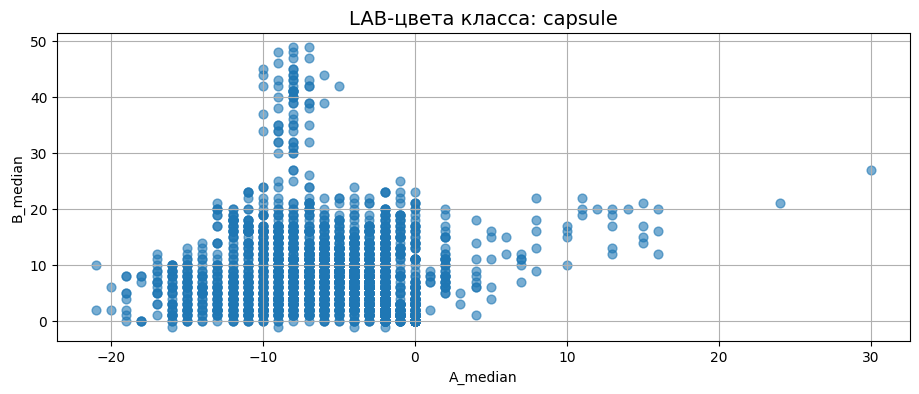

,A_median_round,B_median_round,count
0,-20.0,0.0,8
1,-20.0,5.0,5
2,-20.0,10.0,5
3,-15.0,0.0,46
4,-15.0,5.0,85
5,-15.0,10.0,54
6,-15.0,15.0,8
7,-15.0,20.0,6
8,-10.0,0.0,97
9,-10.0,5.0,242


In [65]:
analyze_class_colors(df, "capsule")

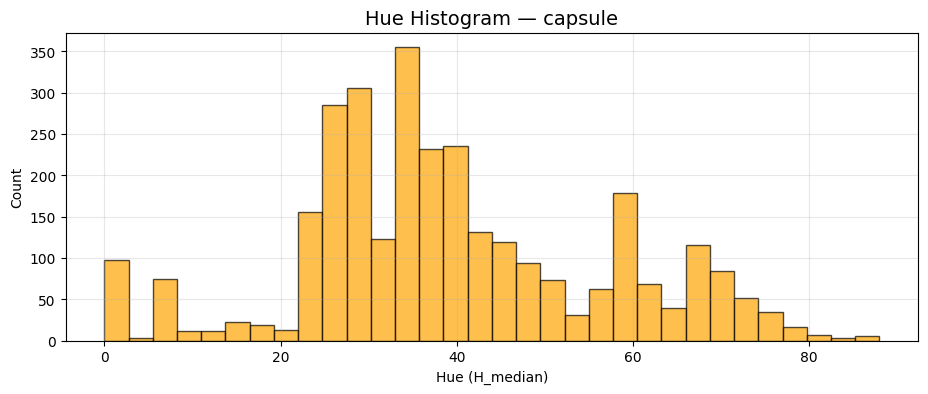

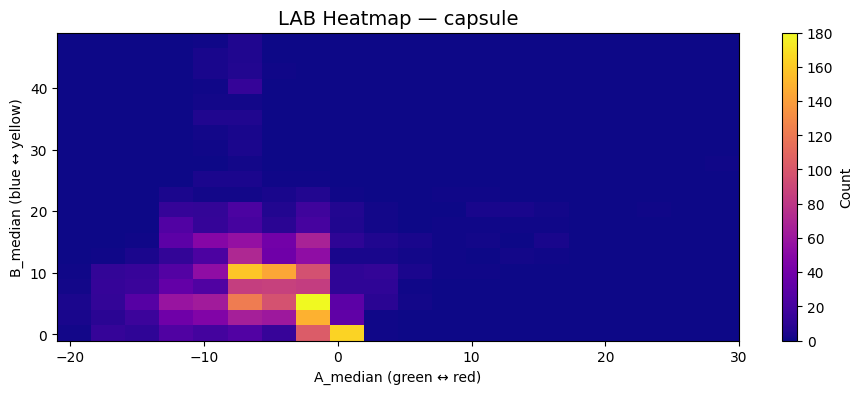

In [66]:
plot_hue_histogram(df, "capsule")
plot_lab_heatmap(df, "capsule")

## "softgel_gelcap"

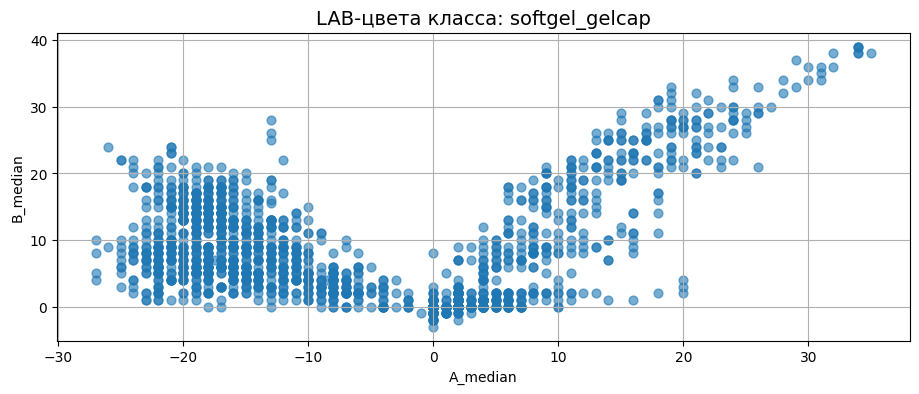

,A_median_round,B_median_round,count
0,-25.0,0.0,5
1,-25.0,5.0,20
2,-25.0,10.0,23
3,-25.0,15.0,3
4,-25.0,20.0,10
...,...,...,...
59,25.0,35.0,3
60,30.0,30.0,1
61,30.0,35.0,9
62,30.0,40.0,1


In [67]:
analyze_class_colors(df, "softgel_gelcap")

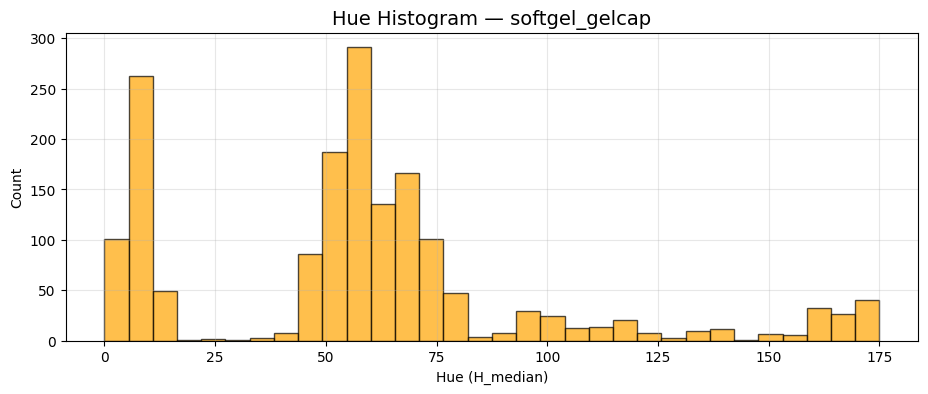

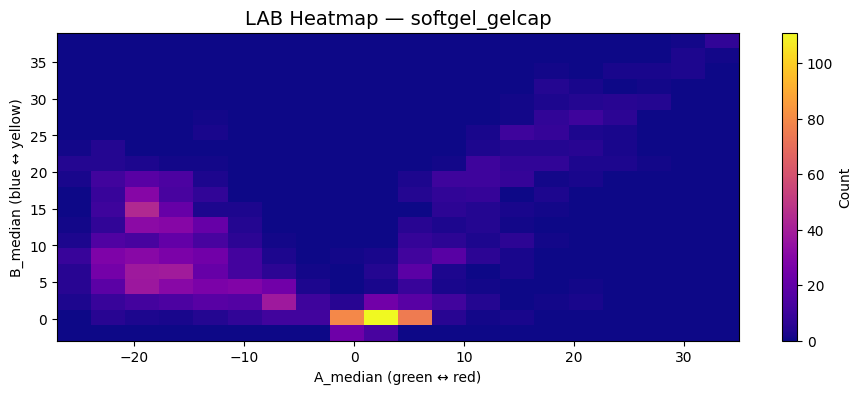

In [68]:
plot_hue_histogram(df, "softgel_gelcap")
plot_lab_heatmap(df, "softgel_gelcap")

## "caplet"

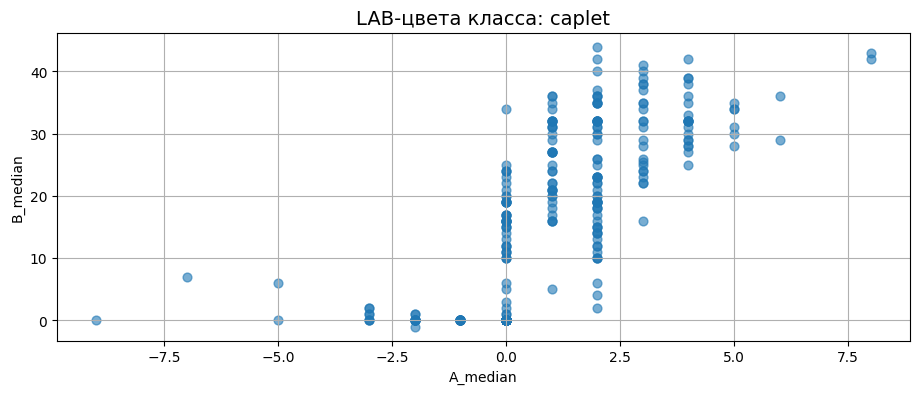

,A_median_round,B_median_round,count
0,-10.0,0.0,1
1,-5.0,0.0,8
2,-5.0,5.0,2
3,0.0,0.0,186
4,0.0,5.0,6
5,0.0,10.0,15
6,0.0,15.0,29
7,0.0,20.0,34
8,0.0,25.0,21
9,0.0,30.0,22


In [69]:
analyze_class_colors(df, "caplet")

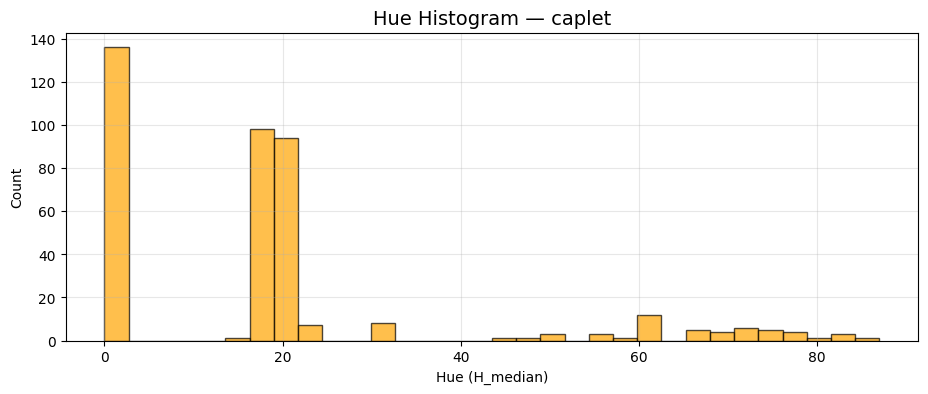

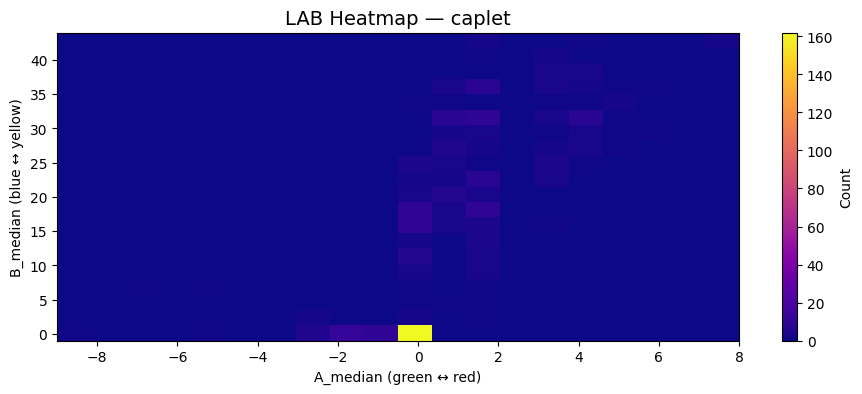

In [70]:
plot_hue_histogram(df, "caplet")
plot_lab_heatmap(df, "caplet")

## "meltlet"

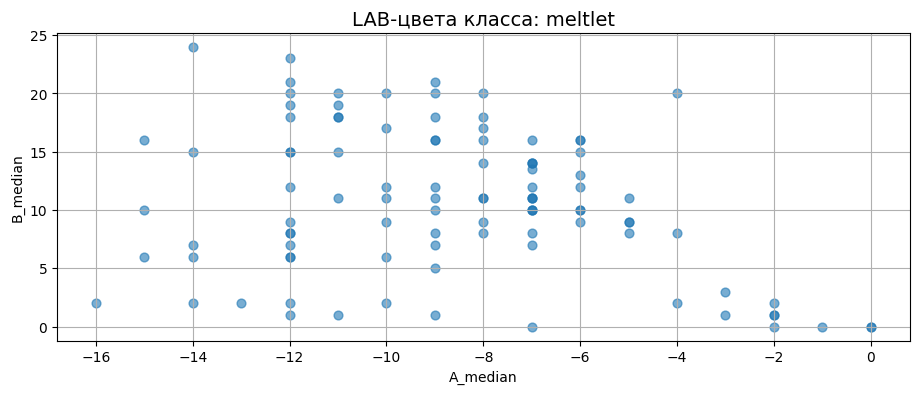

,A_median_round,B_median_round,count
0,-15.0,0.0,3
1,-15.0,5.0,3
2,-15.0,10.0,1
3,-15.0,15.0,2
4,-15.0,25.0,1
5,-10.0,0.0,5
6,-10.0,5.0,6
7,-10.0,10.0,16
8,-10.0,15.0,9
9,-10.0,20.0,14


In [71]:
analyze_class_colors(df, "meltlet")

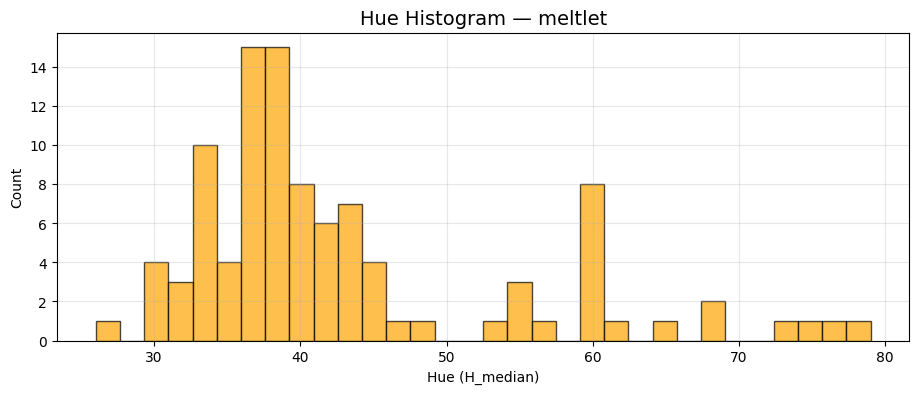

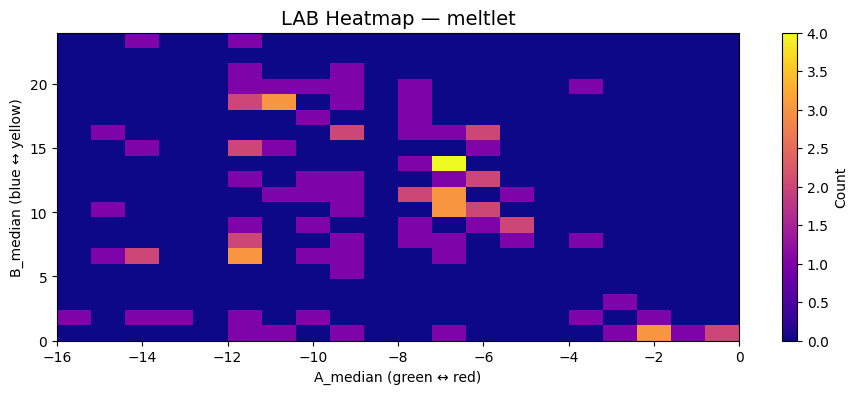

In [72]:
plot_hue_histogram(df, "meltlet")
plot_lab_heatmap(df, "meltlet")

<div style="border:solid green 4px; padding: 5px">

__Выводы по Шагу 5:__
- Получено 22 информативных признака.
- Таблица 5249×22 полностью готова для ML‑классификации цвета.
- Визуальный анализ показывает:
  - capsule — широкий диапазон A/B (много оттенков жёлтого/красного).
  - softgel_gelcap — ярко выраженные кластеры (жёлто‑оранжевые).
  - caplet — почти монотонный цвет (A≈0, B≈0–40).
  - meltlet — компактный кластер (A≈−10, B≈10–20).

Это означает, что классы хорошо разделяются в LAB‑пространстве, и ML‑модель сможет классифицировать цвет с высокой точностью.
    
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch03">к содержанию</a> </b> 
</div>

---

# Шаг 6. Классификация цвета (ML модель) <a class="anchor" id="ch03_6"></a>

## Подготовка разметки

In [28]:
df_color = df.copy()

# Сколько кластеров для каждого класса
cluster_map = {
    "softgel_gelcap": 3,
    "caplet": 2,
    "meltlet": 1,
    "capsule": 7
}

# Пустая колонка для кластерных меток
df_color["color_label_cl"] = None

# Обрабатываем каждый класс отдельно
for cls, K in cluster_map.items():
    subset = df_color[df_color["class_name"] == cls]

    X = subset[["A_median", "B_median"]].values

    kmeans = KMeans(n_clusters=K, random_state=42)
    labels = kmeans.fit_predict(X)

    # Записываем метки обратно в df_color
    df_color.loc[subset.index, "color_label_cl"] = labels

    print(f"\n=== {cls}: центры кластеров ===")
    centers = pd.DataFrame(kmeans.cluster_centers_, columns=["A_center", "B_center"])
    print(centers)
    
cluster_to_color_map = {
    "softgel_gelcap": {
        0: "brown",
        1: "green",
        2: "orange"
    },
    "caplet": {
        0: "white",
        1: "light_orange"
    },
    "meltlet": {
        0: "light_gray"
    },
    "capsule": {
        3: "gray",        
        1: "very_light_gray",
        2: "light_gray",
        4: "yellow",
        0: "dark_green",
        5: "white",
        6: "orange"
    }
}

def map_cluster_to_color(row):
    cls = row["class_name"]
    cl = row["color_label_cl"]
    return cluster_to_color_map[cls][cl]

df_color["color_label_cl_final"] = df_color.apply(map_cluster_to_color, axis=1)

for cls in df_color["class_name"].unique():
    colors = df_color[df_color["class_name"] == cls]["color_label_cl_final"].unique()
    print(f"\nКласс: {cls}")
    print("Цвета:", list(colors))
    
for cls in df_color["class_name"].unique():
    print(f"\n=== Класс: {cls} ===")

    subset_cls = df_color[df_color["class_name"] == cls]

    for color in subset_cls["color_label_cl_final"].unique():
        sub = subset_cls[subset_cls["color_label_cl_final"] == color]

        A_min, A_max = sub["A_median"].min(), sub["A_median"].max()
        B_min, B_max = sub["B_median"].min(), sub["B_median"].max()

        print(f"  Цвет: {color}")
        print(f"    A_median: {A_min:.2f} → {A_max:.2f}")
        print(f"    B_median: {B_min:.2f} → {B_max:.2f}")


=== softgel_gelcap: центры кластеров ===
    A_center   B_center
0   1.852686   2.145581
1 -17.026997   9.429134
2  17.118421  22.890351

=== caplet: центры кластеров ===
   A_center   B_center
0 -0.272727   1.113636
1  2.028736  26.502874

=== meltlet: центры кластеров ===
   A_center  B_center
0     -8.63    10.655

=== capsule: центры кластеров ===
    A_center   B_center
0 -13.832797   5.794212
1  -4.624577   9.988162
2  -6.928261  16.626087
3  -1.701220   2.782927
4  -8.096774  39.322581
5  -8.002114   3.774841
6   9.458333  15.854167

Класс: caplet
Цвета: ['white', 'light_orange']

Класс: capsule
Цвета: ['white', 'dark_green', 'very_light_gray', 'gray', 'light_gray', 'orange', 'yellow']

Класс: meltlet
Цвета: ['light_gray']

Класс: softgel_gelcap
Цвета: ['green', 'orange', 'brown']

=== Класс: caplet ===
  Цвет: white
    A_median: -9.00 → 2.00
    B_median: -1.00 → 13.00
  Цвет: light_orange
    A_median: 0.00 → 8.00
    B_median: 14.00 → 44.00

=== Класс: capsule ===
  Цвет: w

In [29]:
vis_colors = {
    "dark_green":      "#006400",   # тёмно‑зелёный
    "green":           "#00AA00",   # обычный зелёный
    "gray":            "#808080",   # серый
    "light_gray":      "#C0C0C0",   # светло‑серый
    "very_light_gray": "#E8E8E8",   # очень светло‑серый
    "white":           "#FFFFFF",   # белый
    "yellow":          "#FFD700",   # золотисто‑жёлтый
    "orange":          "#FF7F00",   # оранжевый
    "light_orange":    "#FFB347",   # светло‑оранжевый
    "brown":           "#8B4513",   # коричневый

    # запасной цвет
    "unknown":         "#AAAAAA"
}

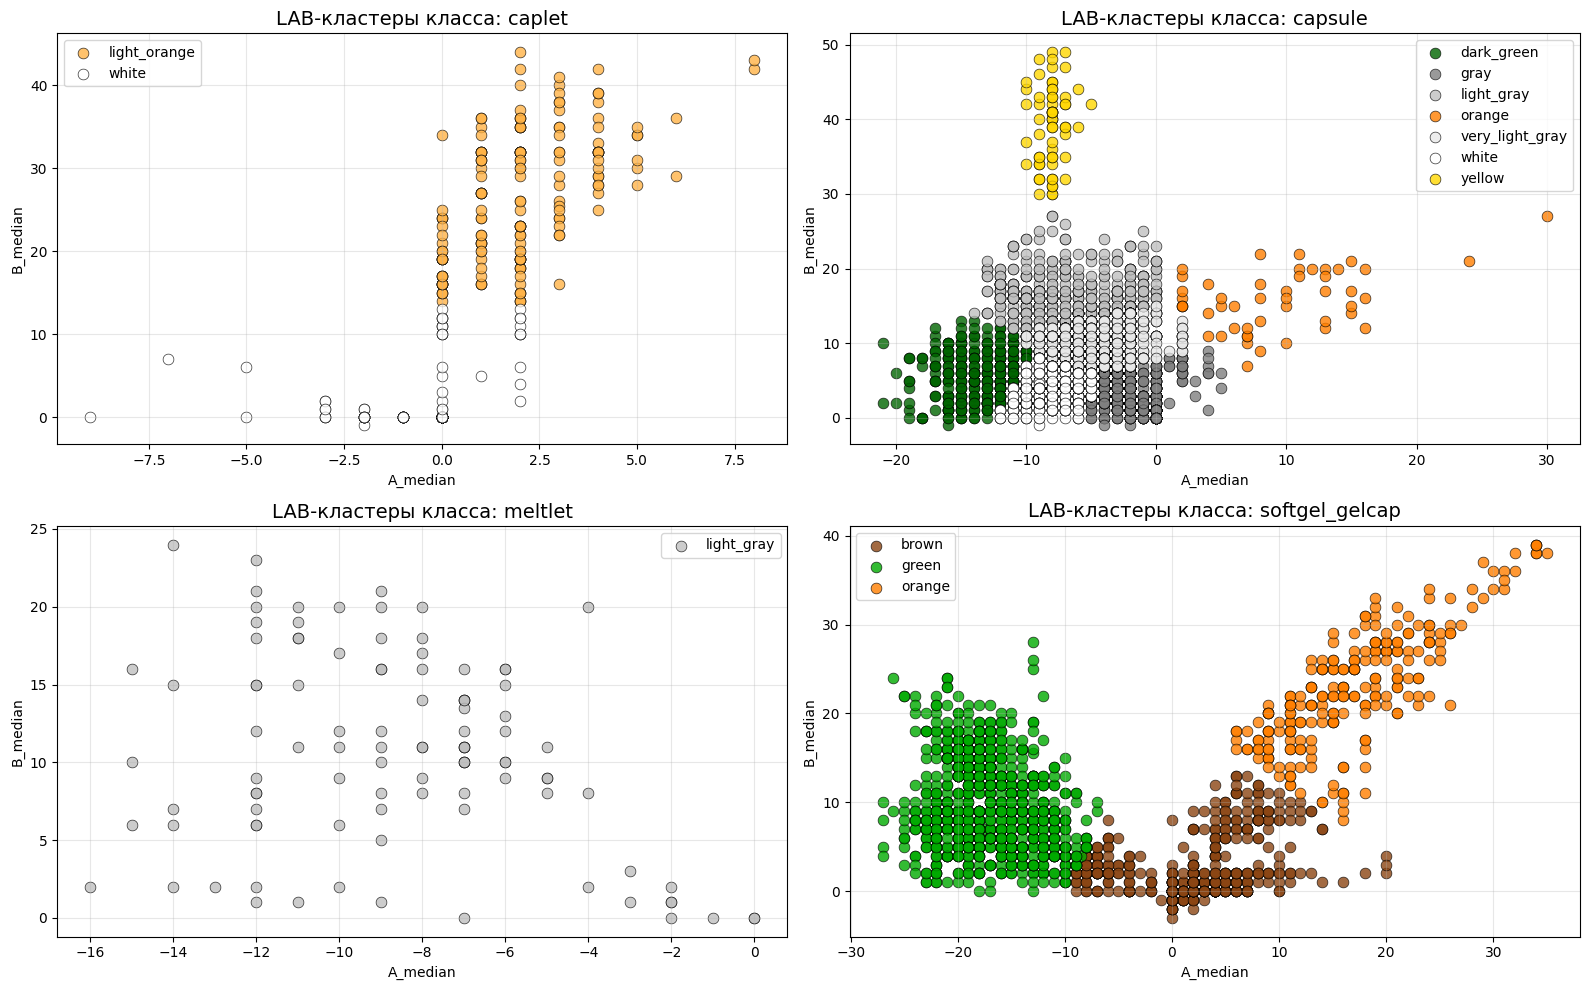

In [30]:
classes = df_color["class_name"].unique()
n = len(classes)

fig, axes = plt.subplots(nrows=(n+1)//2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    subset = df_color[df_color["class_name"] == cls]

    ax.set_title(f"LAB-кластеры класса: {cls}", fontsize=14)

    for color_name in sorted(subset["color_label_cl_final"].unique()):
        sub_cl = subset[subset["color_label_cl_final"] == color_name]

        ax.scatter(
            sub_cl["A_median"],
            sub_cl["B_median"],
            s=60,
            color=vis_colors.get(color_name, vis_colors["unknown"]),
            label=color_name,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5
        )

    ax.set_xlabel("A_median")
    ax.set_ylabel("B_median")
    ax.grid(True, alpha=0.3)
    ax.legend()

# если классов нечётное количество — скрываем пустой subplot
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

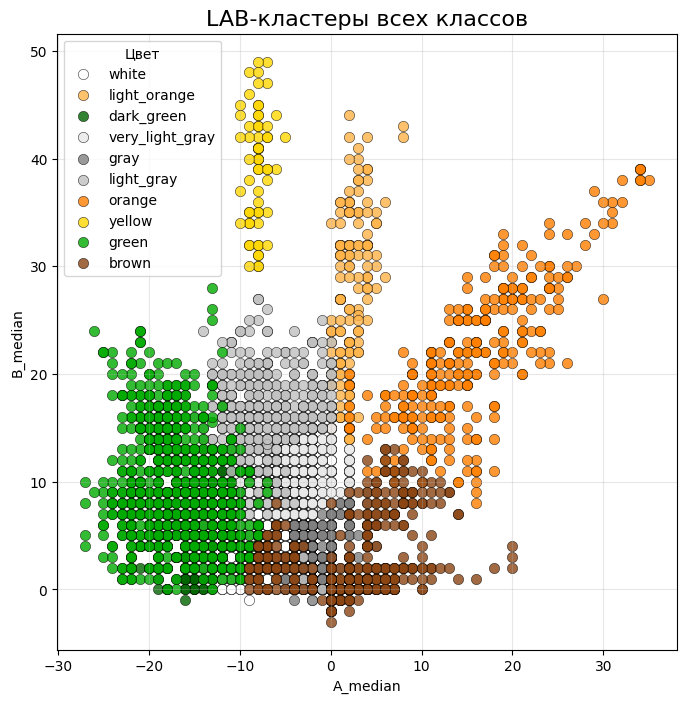

In [31]:
plt.figure(figsize=(8, 8))
plt.title("LAB-кластеры всех классов", fontsize=16)

for color_name in df_color["color_label_cl_final"].unique():
    subset = df_color[df_color["color_label_cl_final"] == color_name]

    plt.scatter(
        subset["A_median"],
        subset["B_median"],
        s=55,
        color=vis_colors.get(color_name, vis_colors["unknown"]),
        label=color_name,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.4
    )

plt.xlabel("A_median")
plt.ylabel("B_median")
plt.grid(True, alpha=0.3)
plt.legend(title="Цвет", fontsize=10)
plt.show()

## Подготовка данных

In [32]:
df_color["color_label_cl_final"].unique()

array(['white', 'light_orange', 'dark_green', 'very_light_gray', 'gray', 'light_gray', 'orange', 'yellow', 'green', 'brown'], dtype=object)

In [33]:
df_color["color_label_cl_final"].nunique()

10

In [34]:
le = LabelEncoder()
y_encoded = le.fit_transform(df_color["color_label_cl_final"])

# Сохраняем классы
class_names = le.classes_
print(class_names)

['brown' 'dark_green' 'gray' 'green' 'light_gray' 'light_orange' 'orange' 'very_light_gray' 'white' 'yellow']


In [35]:
y_encoded 

array([8, 8, 8, ..., 3, 3, 3])

In [36]:
eps = 1e-3
df_color["AB_ratio"] = df_color["A_median"] / (df_color["B_median"] + eps)
df_color["A_L_ratio"] = df_color["A_median"] / (df_color["L_mean"] + eps)
df_color["B_L_ratio"] = df_color["B_median"] / (df_color["L_mean"] + eps)

In [37]:
# Признаки
features = [
    "A_median", "B_median", "L_mean",
    "H_median", "S_mean", "V_mean",
    "LAB_dist_white", "A_std", "B_std",
    "AB_ratio", "A_L_ratio","B_L_ratio" 
]

X = df_color[features]

## Train/Test split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [39]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Обучение моделей

In [76]:
MODEL_DIR = r"03_cd_st6_models"
os.makedirs(MODEL_DIR, exist_ok=True)

### kNN

In [77]:
start = time.time()

knn = KNeighborsClassifier()

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "chebyshev"]
}

knn_gs = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=4,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

knn_gs.fit(X_train_scaled, y_train)
joblib.dump(knn_gs.best_estimator_, os.path.join(MODEL_DIR, "model_knn.pkl"))

print("\n🔥 kNN — лучшие параметры:")
print(knn_gs.best_params_)
print("F1_macro (CV):", knn_gs.best_score_)

end = time.time()
elapsed = end - start
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Fitting 4 folds for each of 30 candidates, totalling 120 fits

🔥 kNN — лучшие параметры:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
F1_macro (CV): 0.9123197207435094
⏱️ Общее время: 0.02 минут (1.3 секунд)


### RandomForest

In [78]:
start = time.time()

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [2400, 2500],
    "max_depth": [20, 25],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True],          
    "class_weight": [None],       
    "criterion": ["log_loss"]
}

rf_rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=32,  # 80
    cv=4,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_rs.fit(X_train, y_train)
joblib.dump(rf_rs.best_estimator_, os.path.join(MODEL_DIR, "model_rf.pkl"))

print("\n🔥 RandomForest — лучшие параметры:")
print(rf_rs.best_params_)
print("F1_macro (CV):", rf_rs.best_score_)

end = time.time()
elapsed = end - start

print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Fitting 4 folds for each of 32 candidates, totalling 128 fits

🔥 RandomForest — лучшие параметры:
{'n_estimators': 2400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 25, 'criterion': 'log_loss', 'class_weight': None, 'bootstrap': True}
F1_macro (CV): 0.9486820610042686
⏱️ Общее время: 4.76 минут (285.6 секунд)


###  XGBoost

In [79]:
start = time.time()

xgb = XGBClassifier(
        random_state=42,
        n_jobs=-1,
        objective="multi:softprob", # "multi:softprob" "multi:softmax"
        num_class=10,
        eval_metric="mlogloss",
        verbosity=0
    )

param_dist_xgb = {
        'n_estimators': [800, 1200, 1600, 2000],
        'max_depth': [4, 5, 6, 7],
        'learning_rate': [0.03, 0.05, 0.07],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'reg_alpha': [0, 0.1, 0.5, 1],
        'reg_lambda': [1, 1.5, 2, 2.5]
    }

xgb_rs = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist_xgb,
        n_iter=80,
        cv=4,
        scoring="f1_macro",
        random_state=42,
        verbose=1,
        n_jobs=-1
    )

xgb_rs.fit(X_train_scaled, y_train)
joblib.dump(xgb_rs.best_estimator_, os.path.join(MODEL_DIR, "model_xgb.pkl"))

print("\n🔥 XGBoost — лучшие параметры:")
print(xgb_rs.best_params_)
print("F1_macro (CV):", xgb_rs.best_score_)
end = time.time()
elapsed = end - start

print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Fitting 4 folds for each of 80 candidates, totalling 320 fits

🔥 XGBoost — лучшие параметры:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 1600, 'max_depth': 6, 'learning_rate': 0.07, 'colsample_bytree': 0.7}
F1_macro (CV): 0.952453956475378
⏱️ Общее время: 3.14 минут (188.6 секунд)


### LightGBM

In [80]:
start = time.time()

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=10,
    random_state=42,
    n_jobs=-1,
    verbosity = -1

)

param_dist_lgbm = {
    "n_estimators": [900, 1200, 1500, 1800],
    "learning_rate": [0.05, 0.07],
    "max_depth": [6],
    "num_leaves": [127, 255],
    "min_child_samples": [10, 20],
    "subsample": [0.8],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0.1, 0.5],
    "reg_lambda": [1, 1.5]
}


lgbm_rs = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=12,
    cv=4,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

lgbm_rs.fit(X_train, y_train)
joblib.dump(lgbm_rs.best_estimator_, os.path.join(MODEL_DIR, "model_lgbm.pkl"))

print("\n🔥 LightGBM  — лучшие параметры:")
print(lgbm_rs.best_params_)
print("F1_macro (CV):", lgbm_rs.best_score_)

end = time.time()
elapsed = end - start
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

Fitting 4 folds for each of 12 candidates, totalling 48 fits

🔥 LightGBM  — лучшие параметры:
{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'num_leaves': 127, 'n_estimators': 1200, 'min_child_samples': 10, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
F1_macro (CV): 0.9533961582774397
⏱️ Общее время: 1.97 минут (118.1 секунд)


## Выбор лучше модели

In [81]:
# ============================================================
# Загрузка моделей с диска
# ============================================================
MODEL_DIR = r"03_cd_st6_models"

knn_model = joblib.load(os.path.join(MODEL_DIR, "model_knn.pkl"))
rf_model  = joblib.load(os.path.join(MODEL_DIR, "model_rf.pkl"))
xgb_model = joblib.load(os.path.join(MODEL_DIR, "model_xgb.pkl"))
lgbm_model = joblib.load(os.path.join(MODEL_DIR, "model_lgbm.pkl"))

print("Модели успешно загружены.")

Модели успешно загружены.


In [82]:
# ============================================================
# Сравнение моделей
# ============================================================
results = pd.DataFrame([
    ["kNN", knn_gs.best_score_],
    ["RandomForest", rf_rs.best_score_],
    ["XGBoost", xgb_rs.best_score_],
    ["LightGBM", lgbm_rs.best_score_],
], columns=["Model", "F1_macro_CV"])

print("\n📊 Сравнение моделей:")
print(results)


📊 Сравнение моделей:
          Model  F1_macro_CV
0           kNN     0.912320
1  RandomForest     0.948682
2       XGBoost     0.952454
3      LightGBM     0.953396


In [83]:
best_model_name = results.sort_values("F1_macro_CV", ascending=False).iloc[0]["Model"]
print("\n🏆 Лучшая модель:", best_model_name)

if best_model_name == "kNN":
    best_model = knn_model
    X_test_final = X_test_scaled

elif best_model_name == "RandomForest":
    best_model = rf_model
    X_test_final = X_test  # RF не требует масштабирования

elif best_model_name == "XGBoost":
    best_model = xgb_model
    X_test_final = X_test_scaled  # XGB обучался на scaled

elif best_model_name == "LightGBM":
    best_model = lgbm_model
    X_test_final = X_test  # LGBM не требует масштабирования

else:
    raise ValueError("Неизвестная модель!")


🏆 Лучшая модель: LightGBM


## Предсказание на тестовой выборке

In [84]:
y_pred = best_model.predict(X_test_final)

##  Матрица ошибок и отчёт по классификации

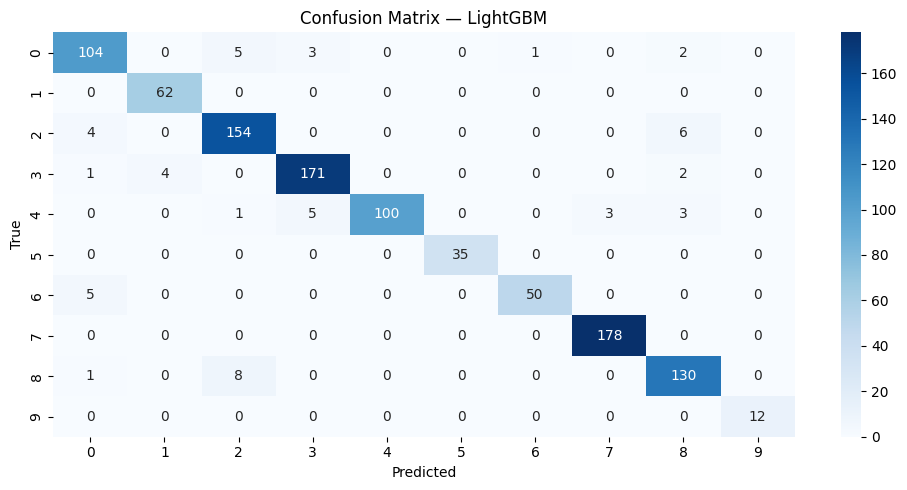


📊 Итоговые метрики:
F1_macro: 0.9559213585209785

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       115
           1       0.94      1.00      0.97        62
           2       0.92      0.94      0.93       164
           3       0.96      0.96      0.96       178
           4       1.00      0.89      0.94       112
           5       1.00      1.00      1.00        35
           6       0.98      0.91      0.94        55
           7       0.98      1.00      0.99       178
           8       0.91      0.94      0.92       139
           9       1.00      1.00      1.00        12

    accuracy                           0.95      1050
   macro avg       0.96      0.95      0.96      1050
weighted avg       0.95      0.95      0.95      1050


🧩 Confusion matrix (raw values):
[[104   0   5   3   0   0   1   0   2   0]
 [  0  62   0   0   0   0   0   0   0   0]
 [  4   0 154   0   0   0   0   0   6   0]
 [

In [85]:
# ============================
# Confusion Matrix + Metrics
# ============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Метрики
print("\n📊 Итоговые метрики:")
print("F1_macro:", f1_score(y_test, y_pred, average="macro"))

print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🧩 Confusion matrix (raw values):")
print(cm)

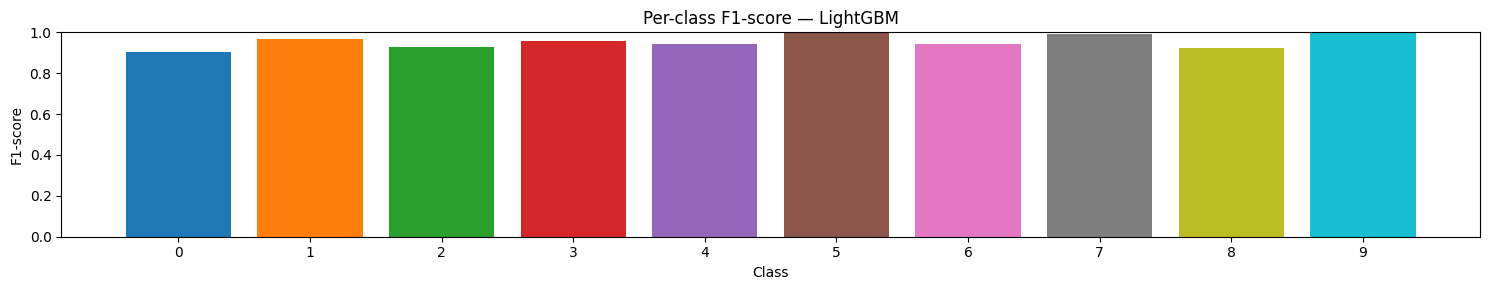

In [86]:
# ============================
# Per-class F1 barplot 
# ============================

report = classification_report(y_test, y_pred, output_dict=True)
df_f1 = pd.DataFrame(report).transpose()

df_f1_classes = df_f1.iloc[:10]

# 10 разных цветов
colors = sns.color_palette("tab10", len(df_f1_classes))

plt.figure(figsize=(15, 3))
plt.bar(
    x=df_f1_classes.index.astype(str),
    height=df_f1_classes["f1-score"],
    color=colors
)

plt.ylim(0, 1)
plt.title(f"Per-class F1-score — {best_model_name}")
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()



📄 Таблица важности признаков:


,feature,importance
0,S_mean,15447
1,A_std,13618
2,B_std,12861
3,L_mean,12320
4,LAB_dist_white,9613
5,AB_ratio,9193
6,V_mean,9116
7,H_median,8656
8,B_L_ratio,8149
9,A_median,8025


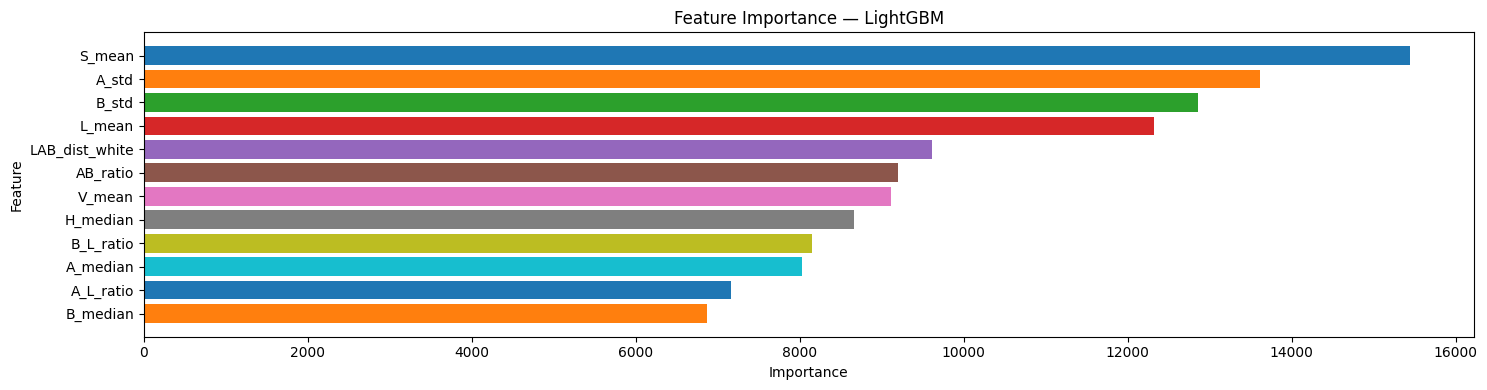

In [87]:
# ============================
# Feature Importance (plt.bar)
# ============================

# Определяем важности
if best_model_name in ["RandomForest", "XGBoost", "LightGBM"]:
    importances = best_model.feature_importances_
else:
    raise ValueError("kNN не имеет feature importance")

feature_names = X_train.columns

# Сортировка
idx = np.argsort(importances)[::-1]
sorted_features = feature_names[idx]
sorted_importances = importances[idx]

# --- Таблица важности ---
df_importance = pd.DataFrame({
    "feature": sorted_features,
    "importance": sorted_importances
})

print("\n📄 Таблица важности признаков:")
display(df_importance)

# --- График ---
plt.figure(figsize=(15, 4))
plt.barh(sorted_features, sorted_importances, color=colors)
plt.gca().invert_yaxis()  # чтобы самый важный был сверху

plt.title(f"Feature Importance — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


##  Качество опредления цвета

In [88]:
cm = confusion_matrix(y_test, y_pred)

errors = []

for true_idx in range(cm.shape[0]):
    true_name = class_names[true_idx]
    
    total = cm[true_idx].sum()
    correct = cm[true_idx, true_idx]
    incorrect = total - correct
    
    misclassified_to = {
        class_names[pred_idx]: int(cm[true_idx, pred_idx])
        for pred_idx in range(cm.shape[1])
        if pred_idx != true_idx and cm[true_idx, pred_idx] > 0
    }
    
    # сортируем ошибки по убыванию
    misclassified_to = dict(sorted(misclassified_to.items(), key=lambda x: -x[1]))
    
    errors.append({
        "class_index": true_idx,
        "class_name": true_name,
        "support": int(total),
        "correct": int(correct),
        "incorrect": int(incorrect),
        "accuracy": round(correct / total, 3),
        "misclassified_to": misclassified_to
    })

df_errors = pd.DataFrame(errors)
df_errors

,class_index,class_name,support,correct,incorrect,accuracy,misclassified_to
0,0,brown,115,104,11,0.904,"{'gray': 5, 'green': 3, 'white': 2, 'orange': 1}"
1,1,dark_green,62,62,0,1.000,{}
2,2,gray,164,154,10,0.939,"{'white': 6, 'brown': 4}"
3,3,green,178,171,7,0.961,"{'dark_green': 4, 'white': 2, 'brown': 1}"
4,4,light_gray,112,100,12,0.893,"{'green': 5, 'very_light_gray': 3, 'white': 3,..."
5,5,light_orange,35,35,0,1.000,{}
6,6,orange,55,50,5,0.909,{'brown': 5}
7,7,very_light_gray,178,178,0,1.000,{}
8,8,white,139,130,9,0.935,"{'gray': 8, 'brown': 1}"
9,9,yellow,12,12,0,1.000,{}


In [89]:
for row in errors:
    print(f"\n🔍 Класс {row['class_index']} — {row['class_name']}")
    print(f"  Всего примеров: {row['support']}")
    print(f"  Верно классифицировано: {row['correct']} ({row['accuracy']*100:.1f}%)")
    print(f"  Ошибок: {row['incorrect']}")
    
    if row["incorrect"] == 0:
        print("  ✔ Нет ошибок")
    else:
        print("  ❌ Ошибки:")
        for pred, count in row["misclassified_to"].items():
            print(f"     → предсказан как {pred}: {count} раз")


🔍 Класс 0 — brown
  Всего примеров: 115
  Верно классифицировано: 104 (90.4%)
  Ошибок: 11
  ❌ Ошибки:
     → предсказан как gray: 5 раз
     → предсказан как green: 3 раз
     → предсказан как white: 2 раз
     → предсказан как orange: 1 раз

🔍 Класс 1 — dark_green
  Всего примеров: 62
  Верно классифицировано: 62 (100.0%)
  Ошибок: 0
  ✔ Нет ошибок

🔍 Класс 2 — gray
  Всего примеров: 164
  Верно классифицировано: 154 (93.9%)
  Ошибок: 10
  ❌ Ошибки:
     → предсказан как white: 6 раз
     → предсказан как brown: 4 раз

🔍 Класс 3 — green
  Всего примеров: 178
  Верно классифицировано: 171 (96.1%)
  Ошибок: 7
  ❌ Ошибки:
     → предсказан как dark_green: 4 раз
     → предсказан как white: 2 раз
     → предсказан как brown: 1 раз

🔍 Класс 4 — light_gray
  Всего примеров: 112
  Верно классифицировано: 100 (89.3%)
  Ошибок: 12
  ❌ Ошибки:
     → предсказан как green: 5 раз
     → предсказан как very_light_gray: 3 раз
     → предсказан как white: 3 раз
     → предсказан как gray: 1 раз

🔍

In [90]:
# ============================
# Predict on full df_color
# ============================

# Берём только те признаки, которые использовались в обучении
X_full = df_color[X_train.columns]

# Предсказания модели
y_full_pred = best_model.predict(X_full)

# Преобразуем индексы обратно в названия классов
predicted_labels = le.inverse_transform(y_full_pred)

# Добавляем колонку в исходный датафрейм
df_color["predicted_color"] = predicted_labels

In [91]:
df_color[['file','class_name', 'color_label_cl_final', 'predicted_color']]

,file,class_name,color_label_cl_final,predicted_color
0,caplet_0001,caplet,white,white
1,caplet_0002,caplet,white,white
2,caplet_0003,caplet,white,white
3,caplet_0004,caplet,white,white
4,caplet_0005,caplet,white,white
...,...,...,...,...
5244,softgel_gelcap_1690,softgel_gelcap,green,green
5245,softgel_gelcap_1691,softgel_gelcap,green,green
5246,softgel_gelcap_1692,softgel_gelcap,green,green
5247,softgel_gelcap_1693,softgel_gelcap,green,green


In [92]:
df_mismatch = df_color[df_color["color_label_cl_final"] != df_color["predicted_color"]]
df_mismatch[["file", "class_name", "color_label_cl_final", "predicted_color"]]

,file,class_name,color_label_cl_final,predicted_color
6,caplet_0007,caplet,white,gray
18,caplet_0019,caplet,white,gray
56,caplet_0057,caplet,white,gray
61,caplet_0062,caplet,white,gray
114,caplet_0115,caplet,white,gray
135,caplet_0136,caplet,white,gray
143,caplet_0144,caplet,white,gray
192,caplet_0193,caplet,white,gray
498,capsule_0105,capsule,gray,white
576,capsule_0183,capsule,gray,white


<div style="border:solid green 4px; padding: 5px">

__Выводы по Шагу 6:__
- Для каждого класса объектов выполняется KMeans‑кластеризация по (A_median, B_median).
- Кластеры вручную сопоставляются с цветами:
  - white, gray, light_gray, very_light_gray
  - green, dark_green
  - orange, light_orange
  - brown
  - yellow
- Обучаются ML‑модели:
  - kNN
  - RandomForest
  - XGBoost
  - LightGBM
- Выбирается лучшая модель → LightGBM
- Описание данных
  - 10 цветовых классов
  - 5249 объектов
  - 12 признаков для обучения
- Выбор метрик
  - Используются:
    - F1_macro (главная метрика)
    - Confusion Matrix
    - Per‑class F1
    - Feature Importance
- Результаты CV F1_macro:
  - kNN 0.912
  - RandomForest 0.949
  - XGBoost 0.952
  - LightGBM 0.953
- Тестовая выборка:
  - F1_macro = 0.956
  - Accuracy = 95%
- Выводы
  - LightGBM показывает лучшее качество и стабильность.
  - Ошибки в основном между близкими оттенками (white/gray/light_gray).
  - Цвета с высокой насыщенностью (orange, green, yellow) классифицируются идеально.
  - Признаки S_mean, A_std, B_std — наиболее важные.

📌 Итоговый вывод по проекту
- Построил полный промышленный пайплайн определения цвета объектов, включающий:
  - детекцию объектов YOLO
  - очистку кропов
  - удаление бликов
  - выделение валидных пикселей
  - извлечение цветовых признаков
  - кластеризацию LAB‑пространства
  - обучение ML‑классификатора
- Итоговая точность:
  - 95.6% F1_macro на 10 цветовых классов
</div>

<div class="alert alert-info">
  <b> * <a href="#ch03">к содержанию</a> </b> 
</div>

---

In [56]:
elapsed_all = time.time() - start_all
print(f"Время выполнения: {elapsed_all:.2f} сек ({elapsed_all/60:.2f} мин)")

Время выполнения: 1575.48 сек (26.26 мин)
